In [181]:
# import libraries
import numpy as np
from sklearn.metrics import precision_score, accuracy_score, recall_score, f1_score

# recreate the dataset above
y_true = np.zeros(1000)
y_true[-10:]=1
y_pred = np.zeros(1000)
y_pred[:11]=1
y_pred[-1:] = 1

# compute the scores
print('accuracy:', accuracy_score(y_true, y_pred))
print('precision:', precision_score(y_true, y_pred))
print('recall:', recall_score(y_true, y_pred))
print('F1-score:', f1_score(y_true, y_pred))

accuracy: 0.98
precision: 0.08333333333333333
recall: 0.1
F1-score: 0.09090909090909091


In [182]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import time

from mpl_toolkits.mplot3d import axes3d, Axes3D
from mpl_toolkits.mplot3d import proj3d

from sklearn.model_selection import train_test_split

In [183]:
from pathlib import Path

# Load data regardless of whether the notebook is started from the repo root or this folder.
data_path = Path('creditcard.csv')
if not data_path.exists():
    data_path = Path('05-Anomaly-Detection') / 'creditcard.csv'

credit = pd.read_csv(data_path)
credit.head(10)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [184]:
print(credit.columns)

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')


In [185]:
credit.isnull().sum()
credit.duplicated().sum()
 

np.int64(1081)

In [186]:
print(credit.shape)

(284807, 31)


In [187]:
credit = credit.drop_duplicates()

In [188]:
credit.duplicated().sum()

np.int64(0)

In [189]:
print(credit.shape)

(283726, 31)


In [190]:
credit.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


In [191]:
percentage_fraud = round((credit['Class'].value_counts()[1] / len (credit)) * 100, 2)
percentage_no_fraud = round((credit['Class'].value_counts()[0] / len (credit)) * 100, 2)

print('Pourcentage Fraud transactions : ', percentage_fraud)
print('Pourcentage No_Fraud transactions : ', percentage_no_fraud)

Pourcentage Fraud transactions :  0.17
Pourcentage No_Fraud transactions :  99.83


In [192]:
Fraud = credit[credit['Class'] == 1]
Valid = credit[credit['Class'] == 0]

print("Fraud Cases: {}".format(len(credit[credit['Class'] == 1])))
print("Valid Transactions: {}".format(len(credit[credit['Class'] == 0])))

Fraud Cases: 473
Valid Transactions: 283253


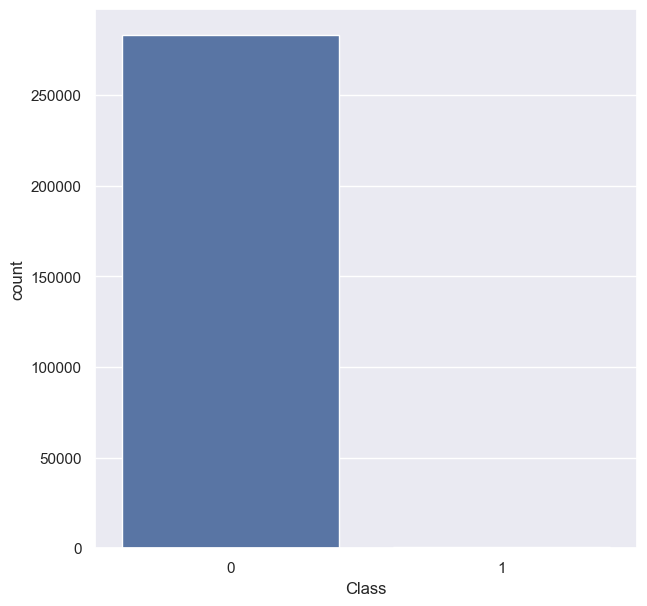

In [193]:
plt.figure(figsize=(7,7))
sns.set(style="darkgrid")
sns.countplot(x="Class", data=credit)
plt.show()
 

In [194]:
# explore the dataset
print(credit.columns)
 

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')


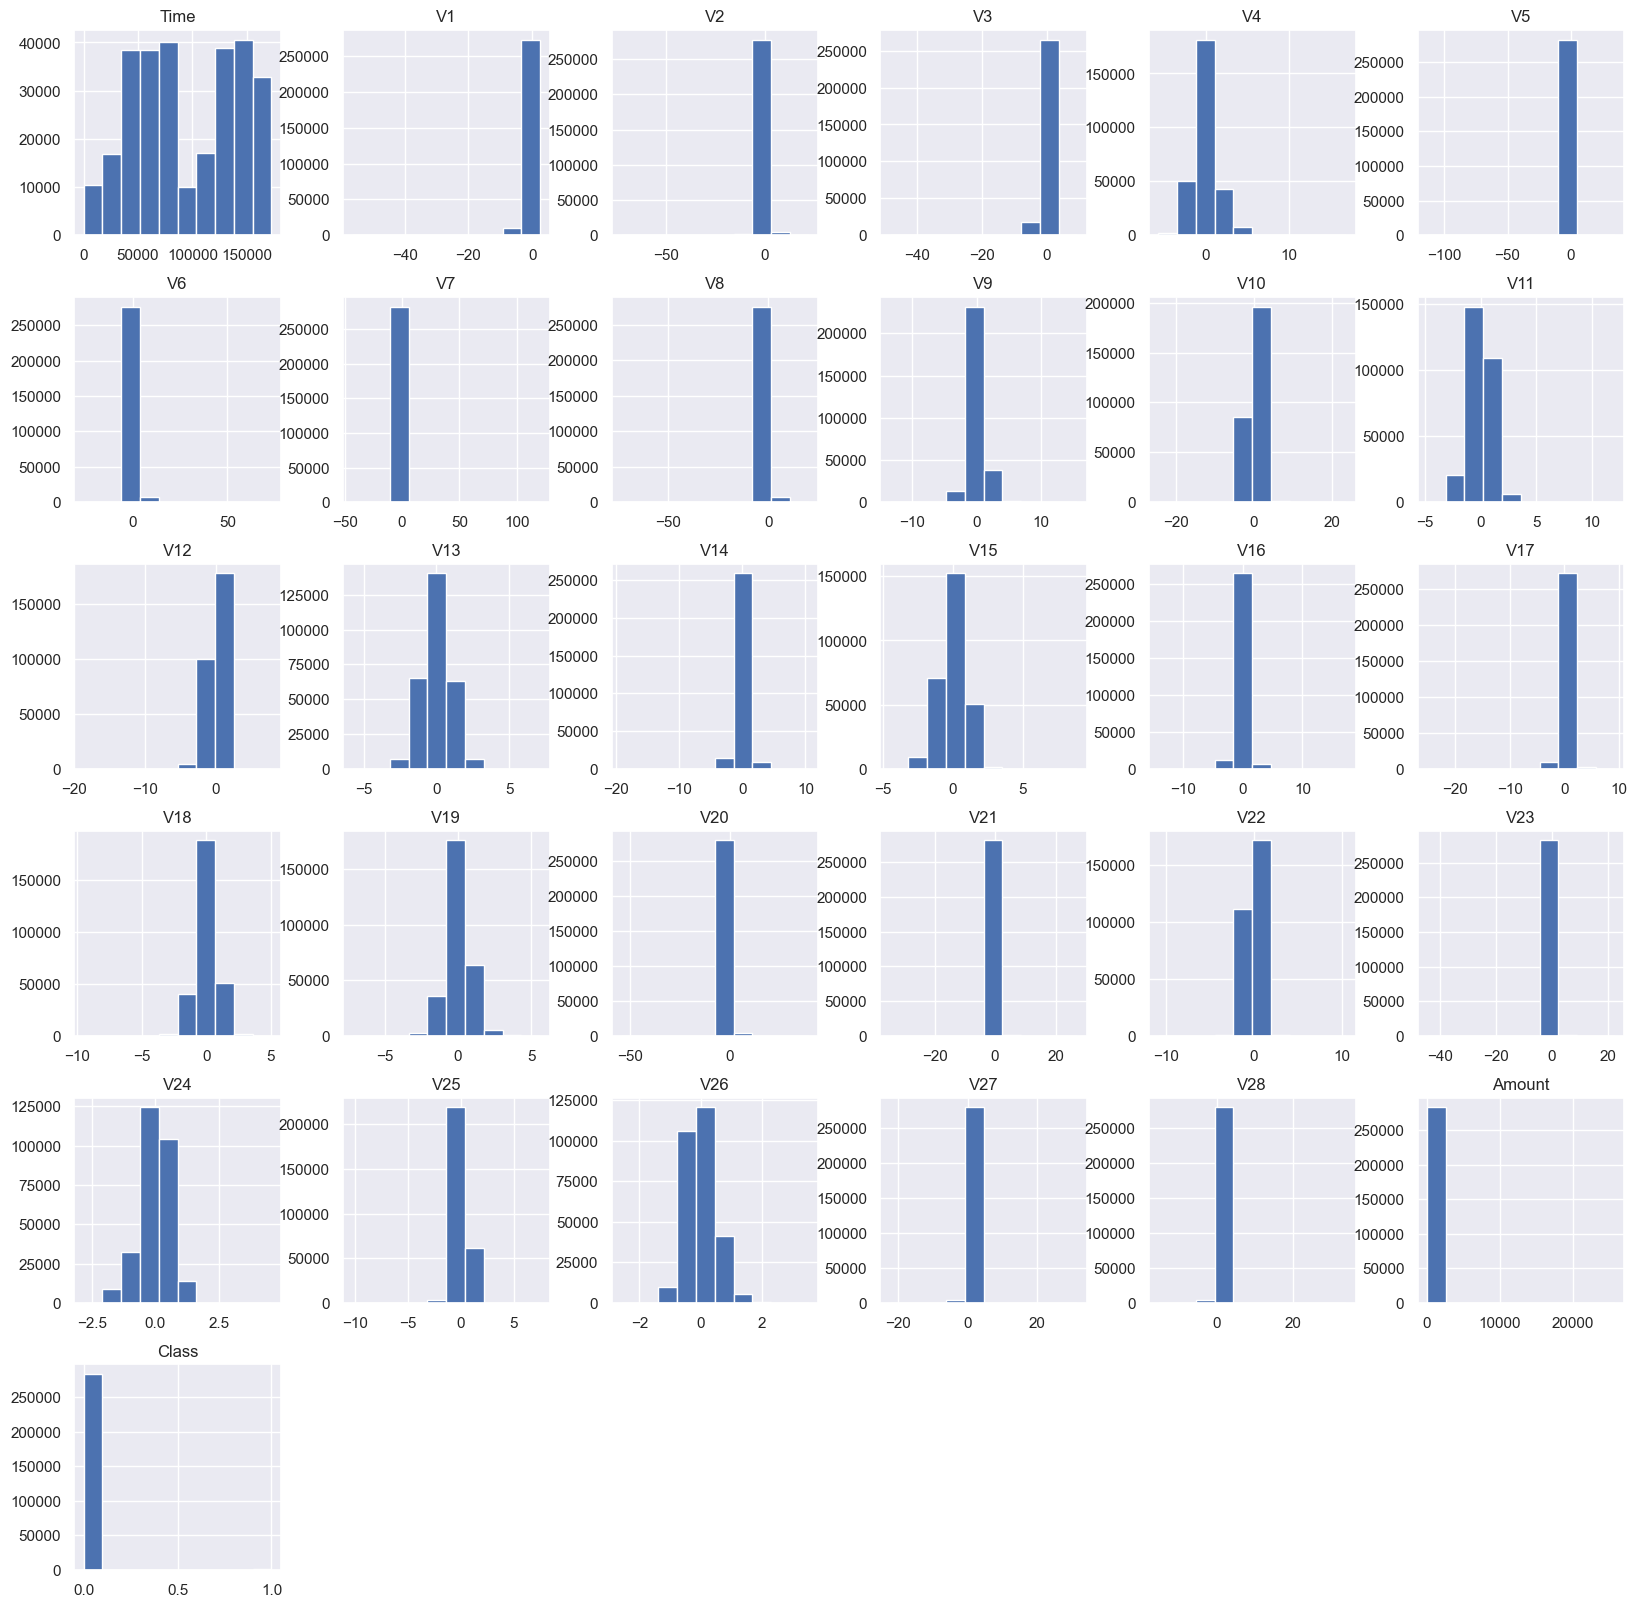

In [195]:
credit.hist(figsize = (20, 20))
plt.show()

In [196]:
credit.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [197]:
print(credit.shape)

(283726, 31)


In [198]:
credit.describe()
 

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


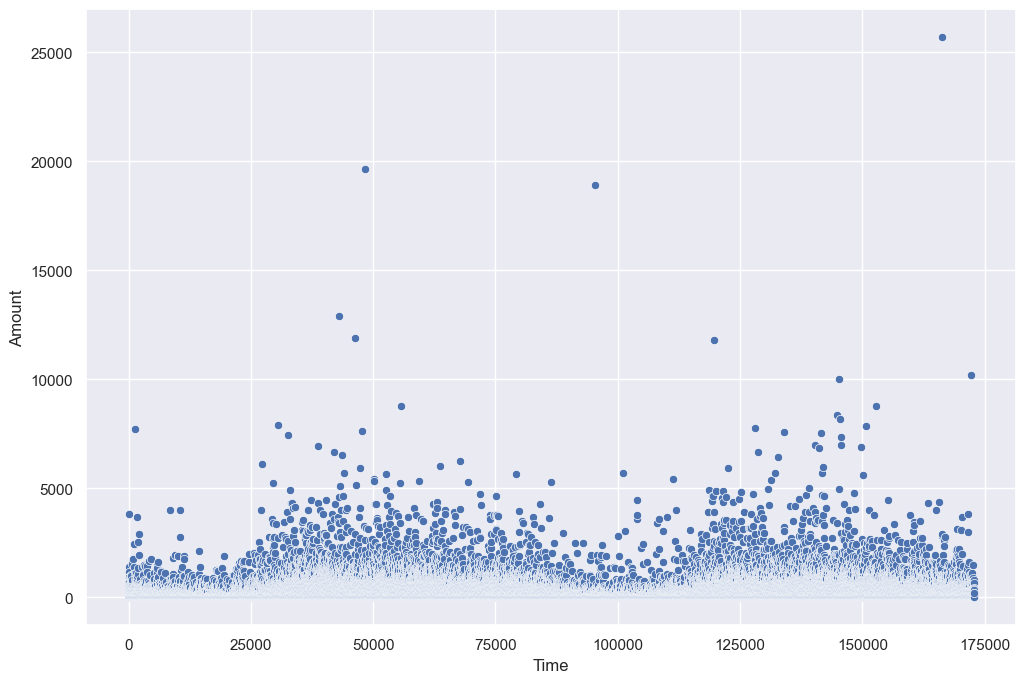

In [199]:
#Scatter plot of the amount over time
plt.figure(figsize=(12,8))
sns.scatterplot(x=credit['Time'], y=credit['Amount'])
plt.show()
 

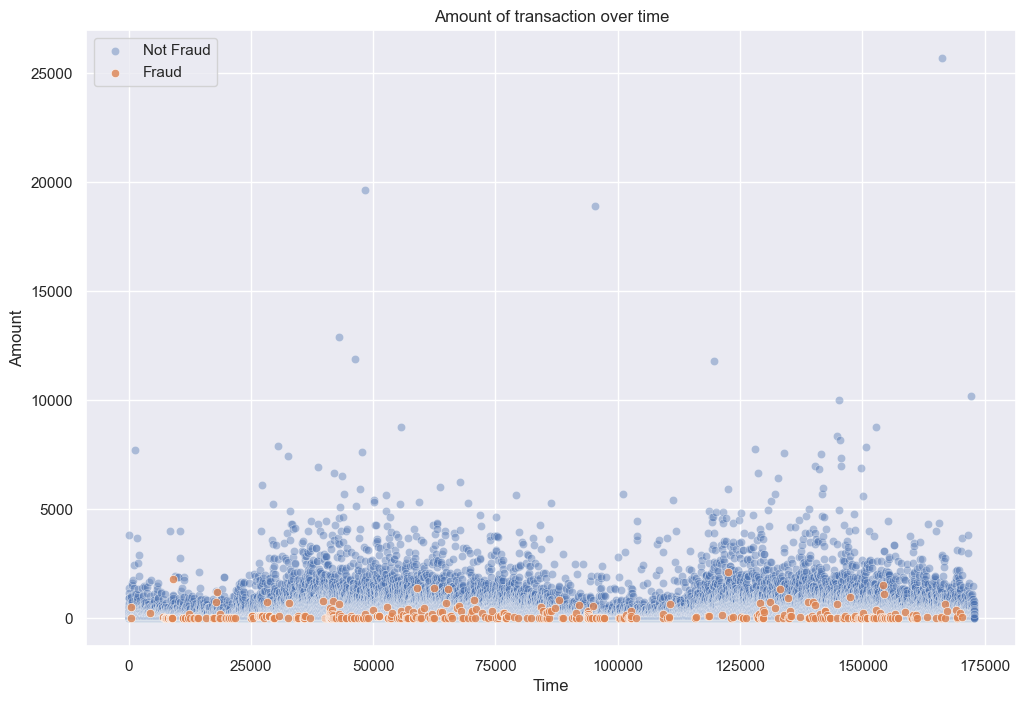

In [200]:
plt.figure(figsize=(12,8))
sns.scatterplot(x=Valid.Time, y= Valid.Amount, alpha = 0.4, label = "Not Fraud")
sns.scatterplot(x=Fraud.Time, y= Fraud.Amount, alpha = 0.8, label = "Fraud")

plt.title("Amount of transaction over time")
plt.legend()
plt.show()

In [201]:
credit['Time_day'] = credit['Time'].apply(lambda x : x/3600 %24)

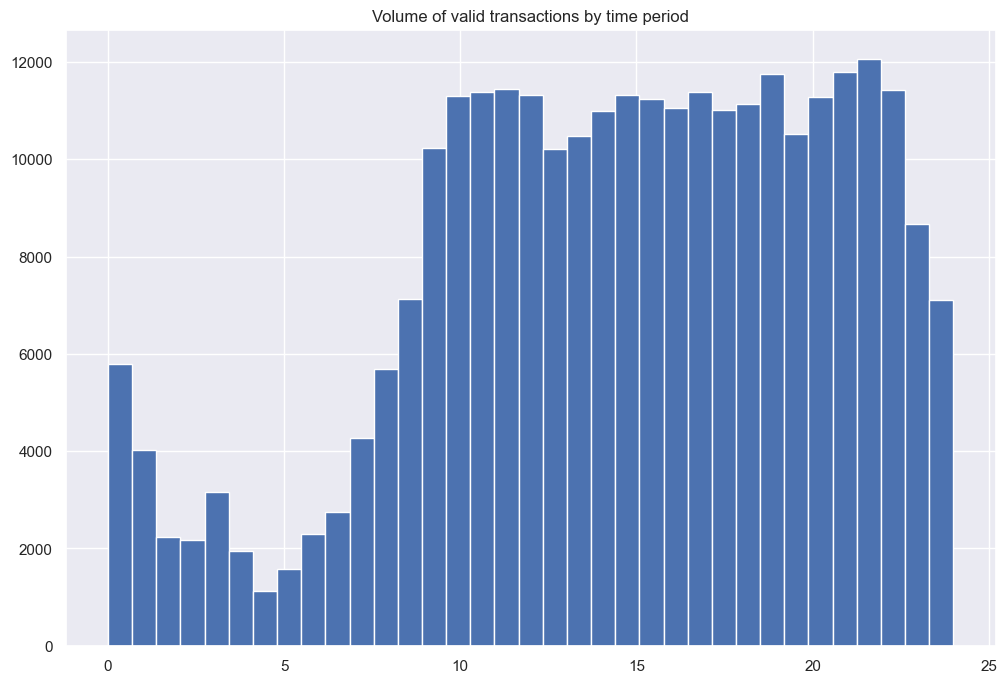

In [202]:
Valid = credit[credit["Class"]==0]

plt.figure(figsize=(12,8))
Valid["Time_day"].hist(bins=35)
plt.title("Volume of valid transactions by time period")
plt.show()

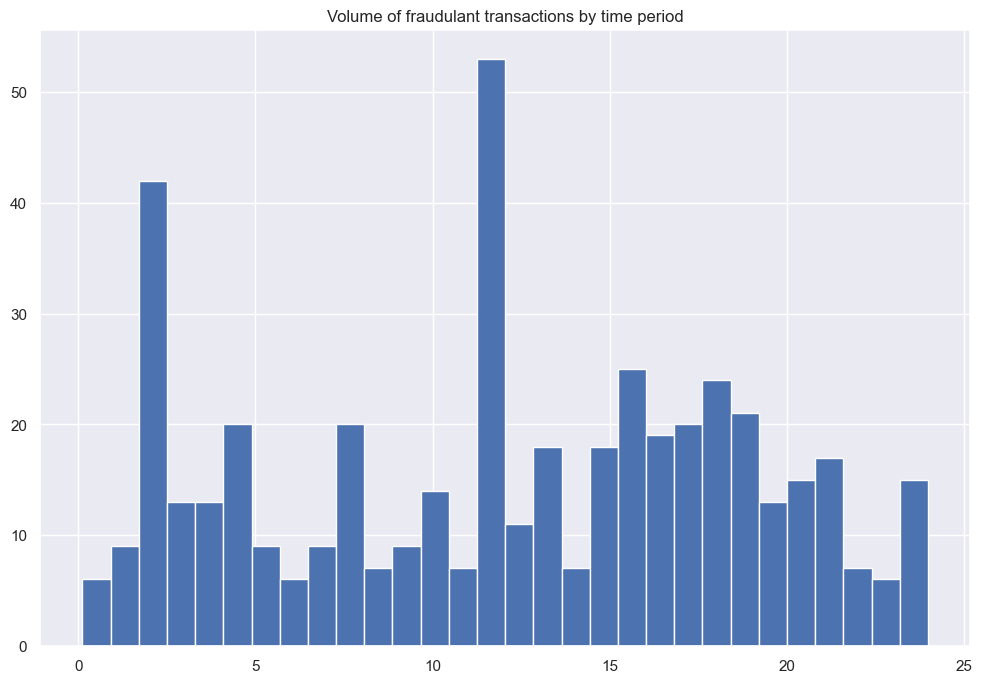

In [203]:
Fraud = credit[credit["Class"]==1]

plt.figure(figsize=(12,8))
Fraud["Time_day"].hist(bins=30)
plt.title("Volume of fraudulant transactions by time period")
plt.show()

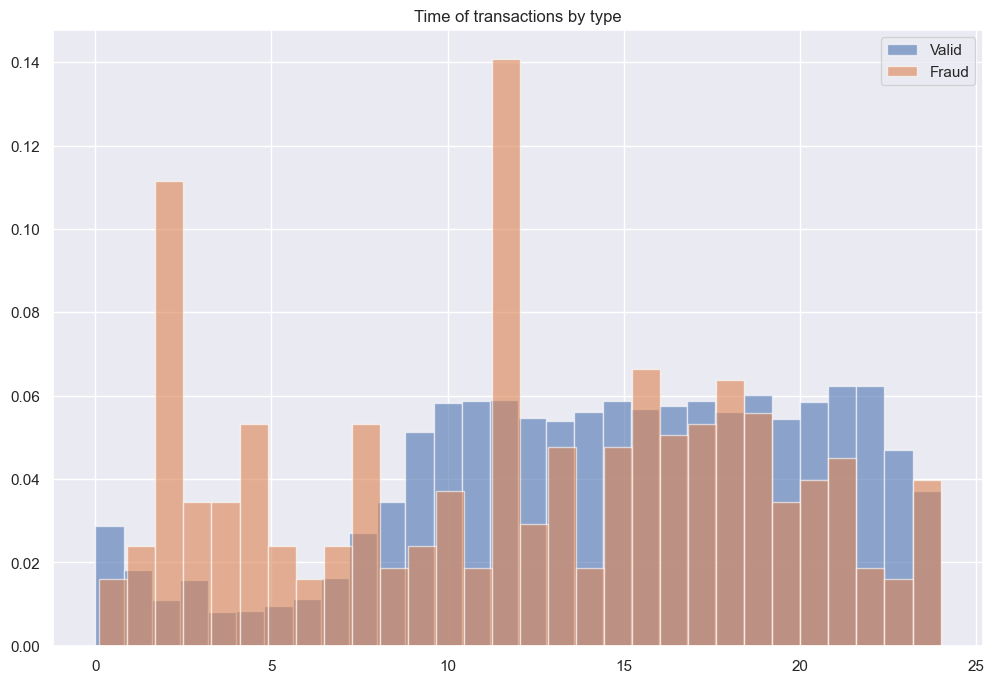

In [204]:
plt.figure(figsize=(12,8))
Valid["Time_day"].hist(bins=30, density=True, alpha=0.6, label ="Valid")
Fraud["Time_day"].hist(bins=30, density=True, alpha=0.6, label ="Fraud")
plt.title("Time of transactions by type")
plt.legend()
plt.show()

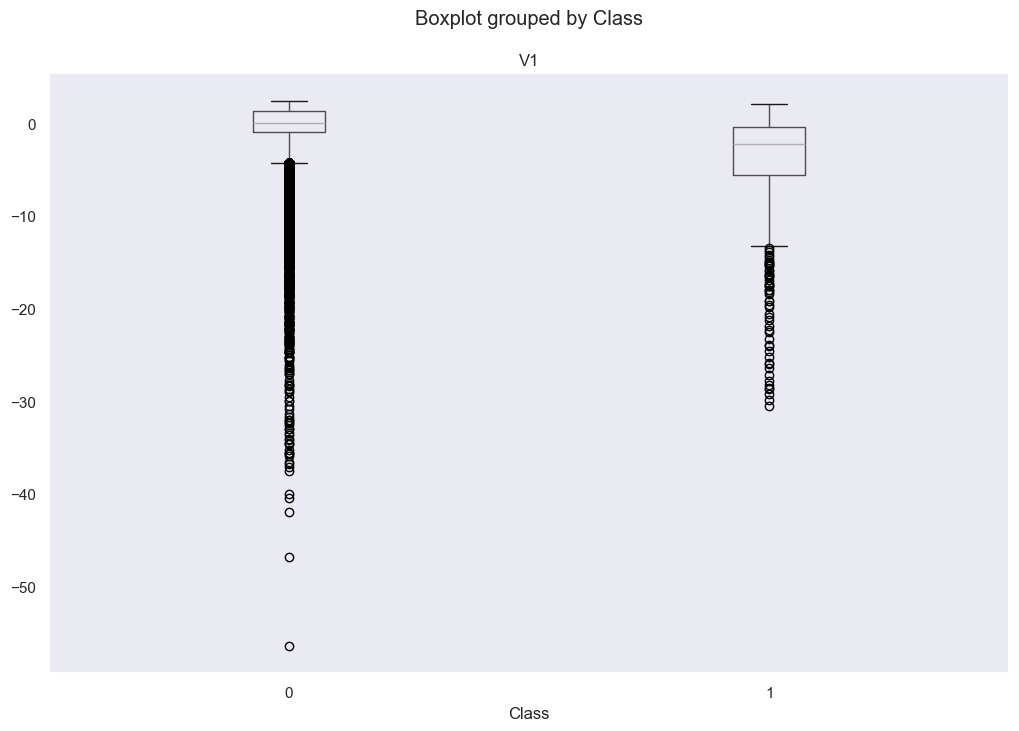

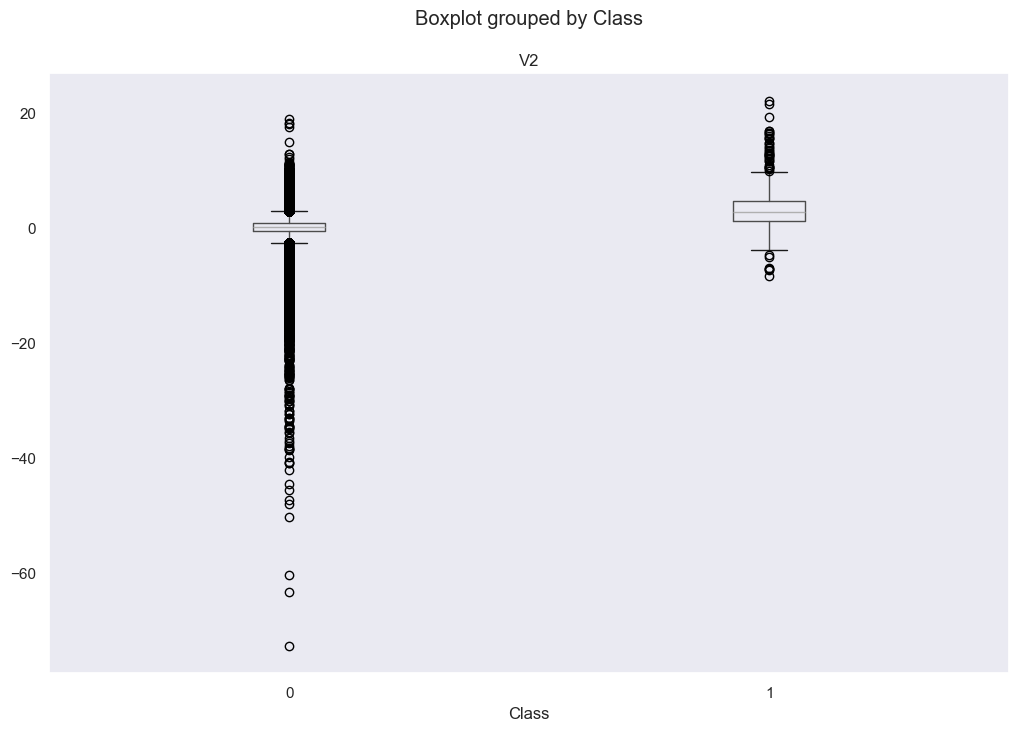

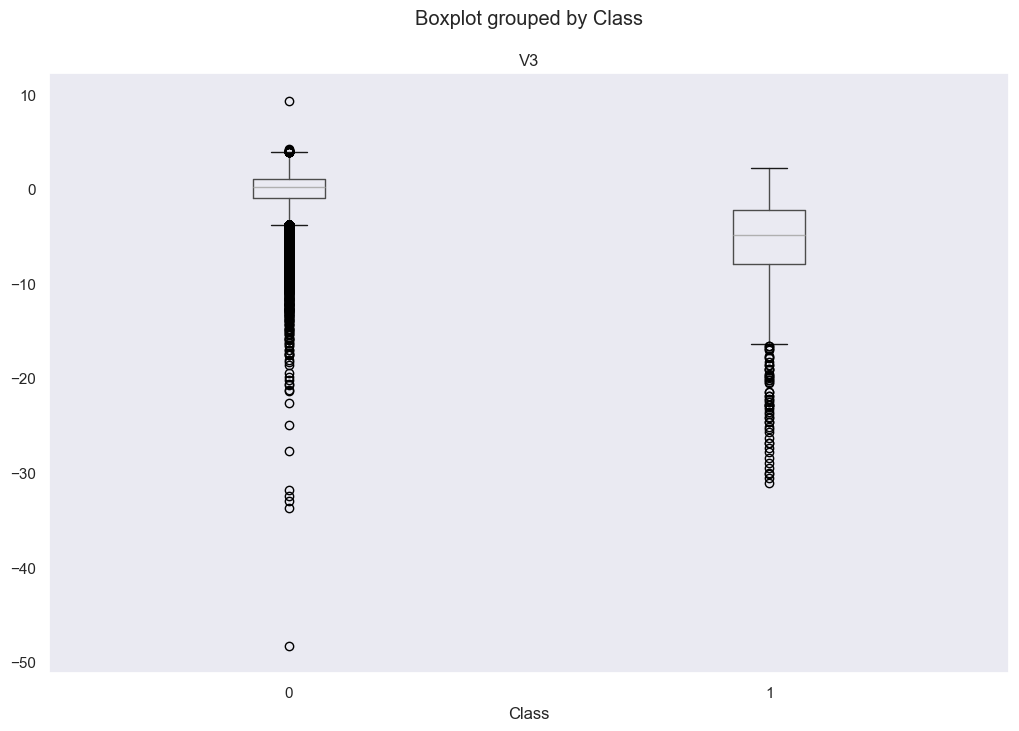

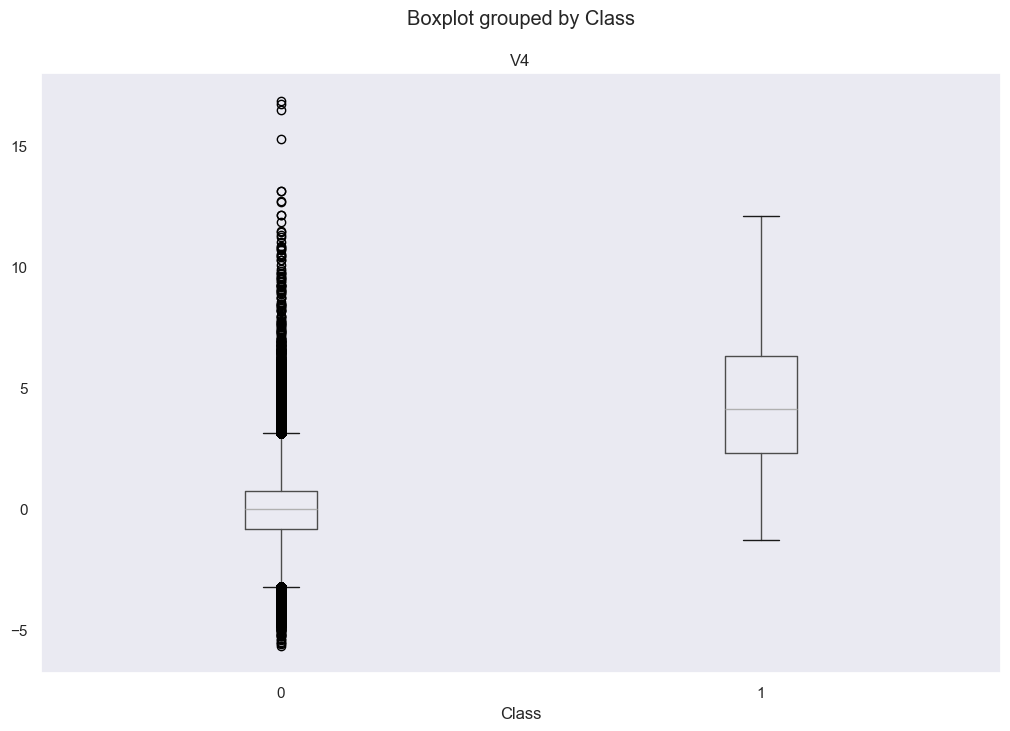

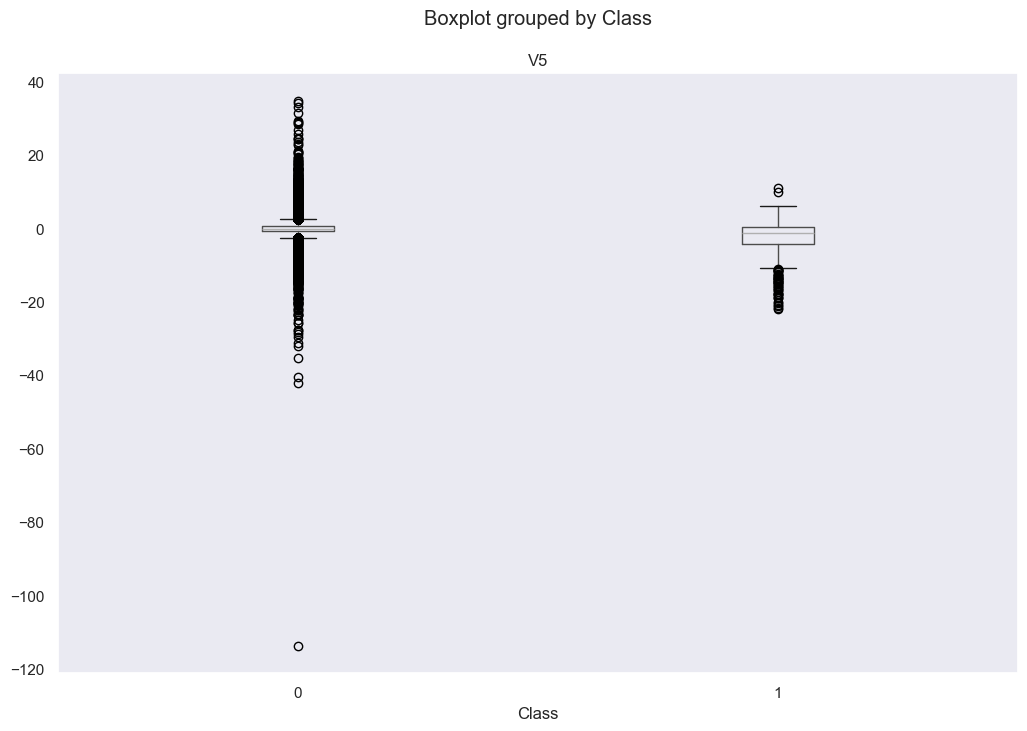

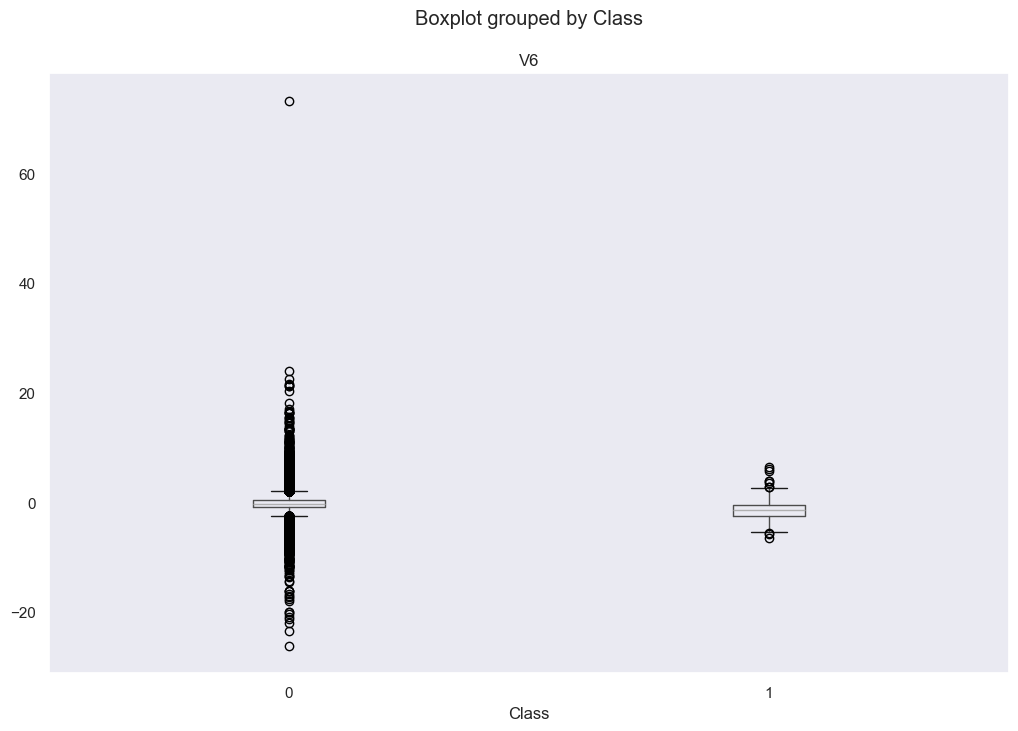

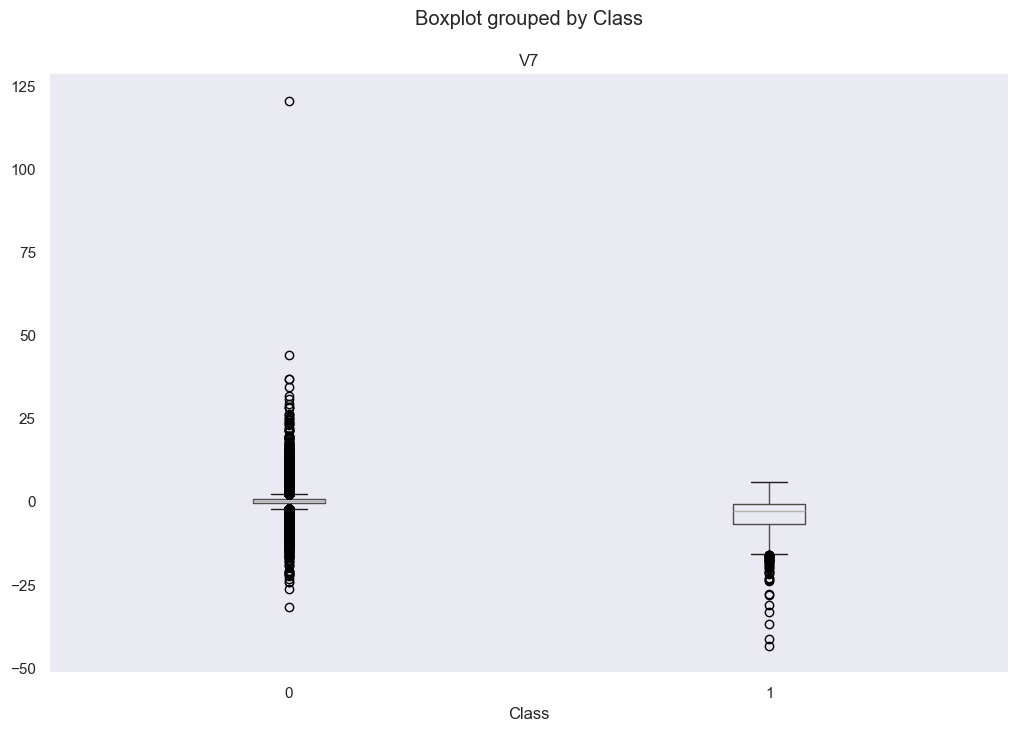

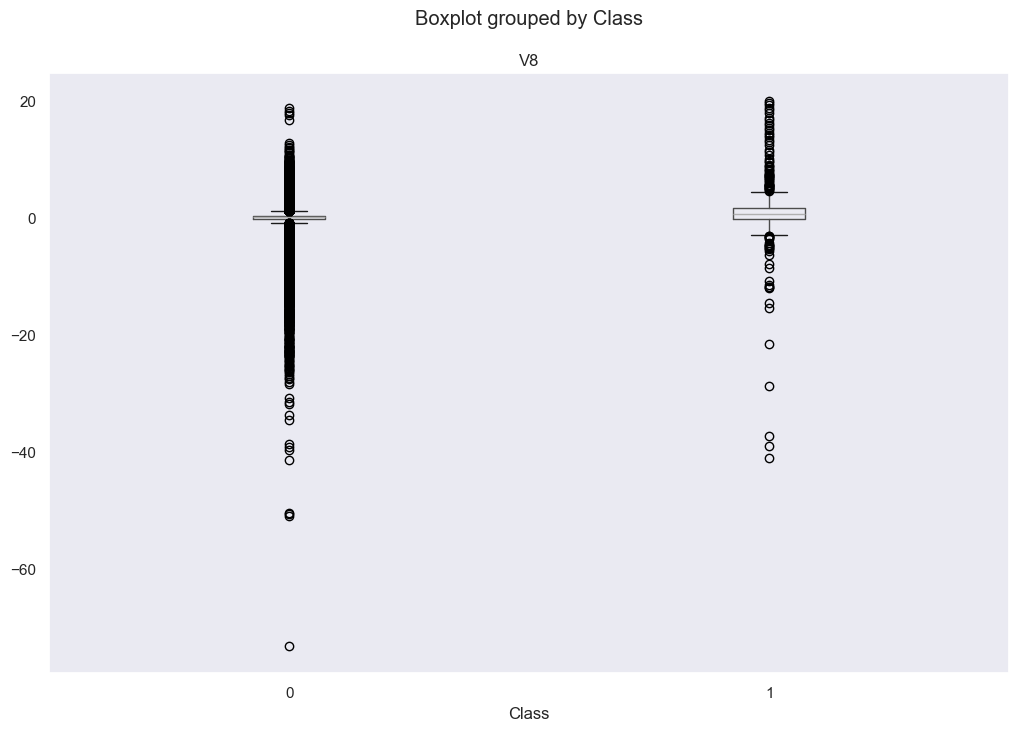

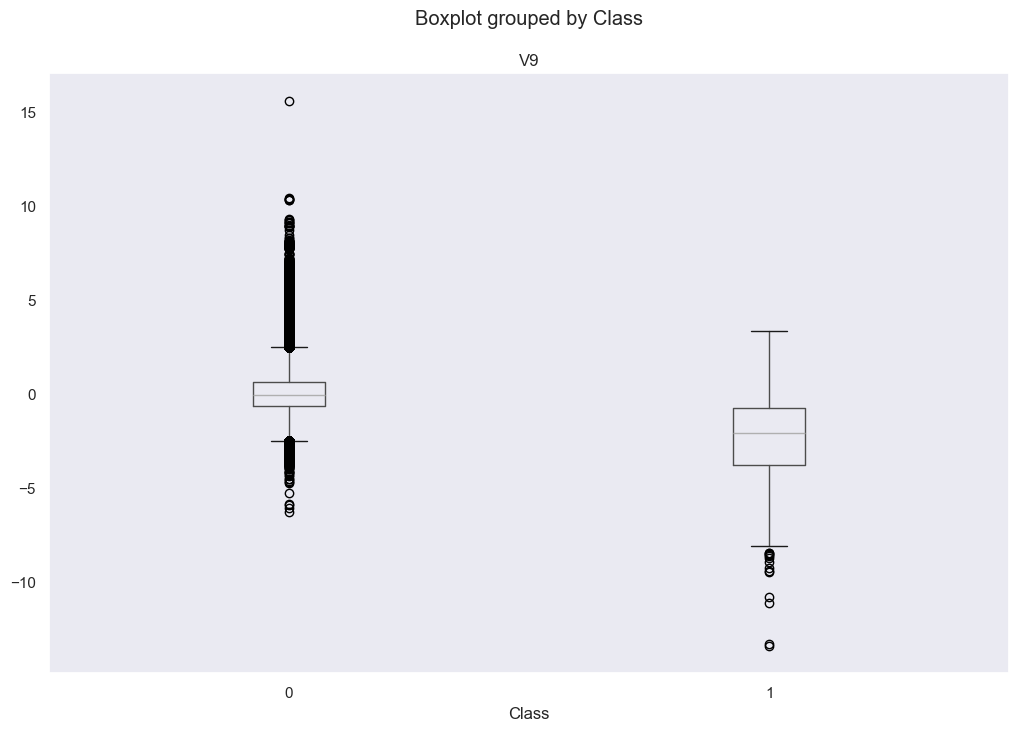

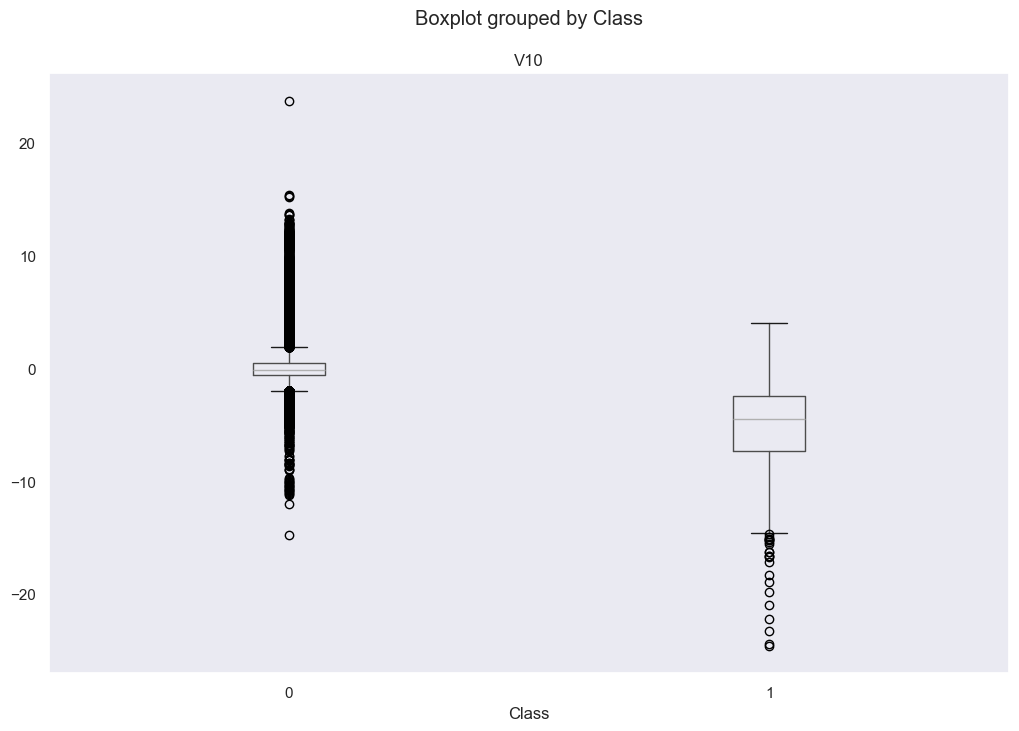

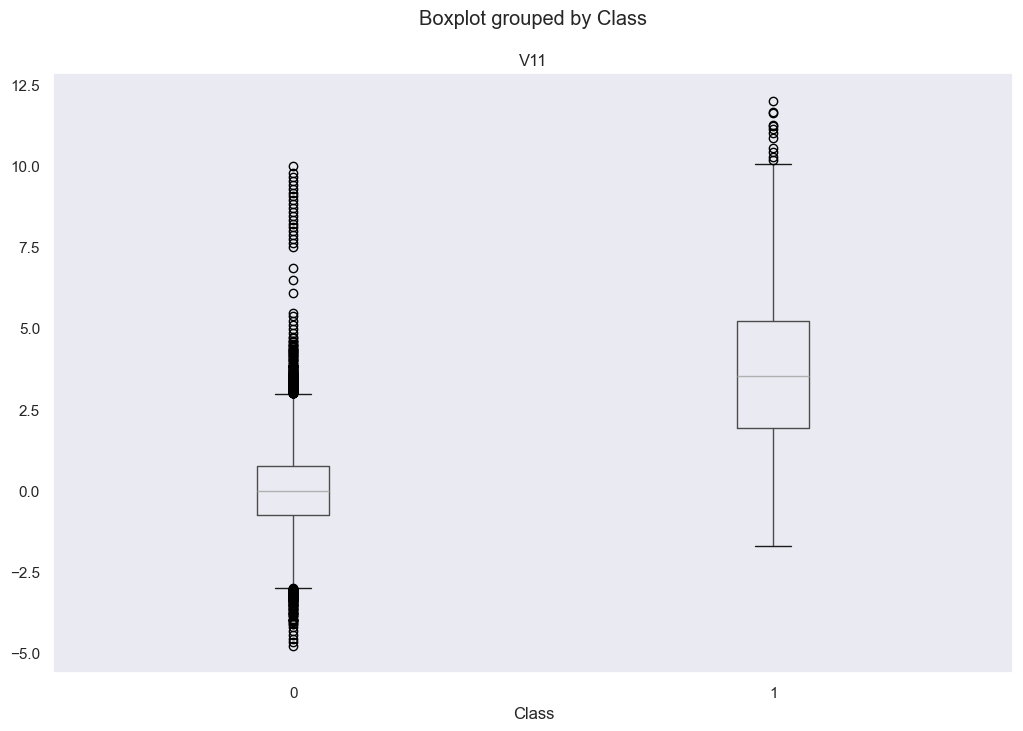

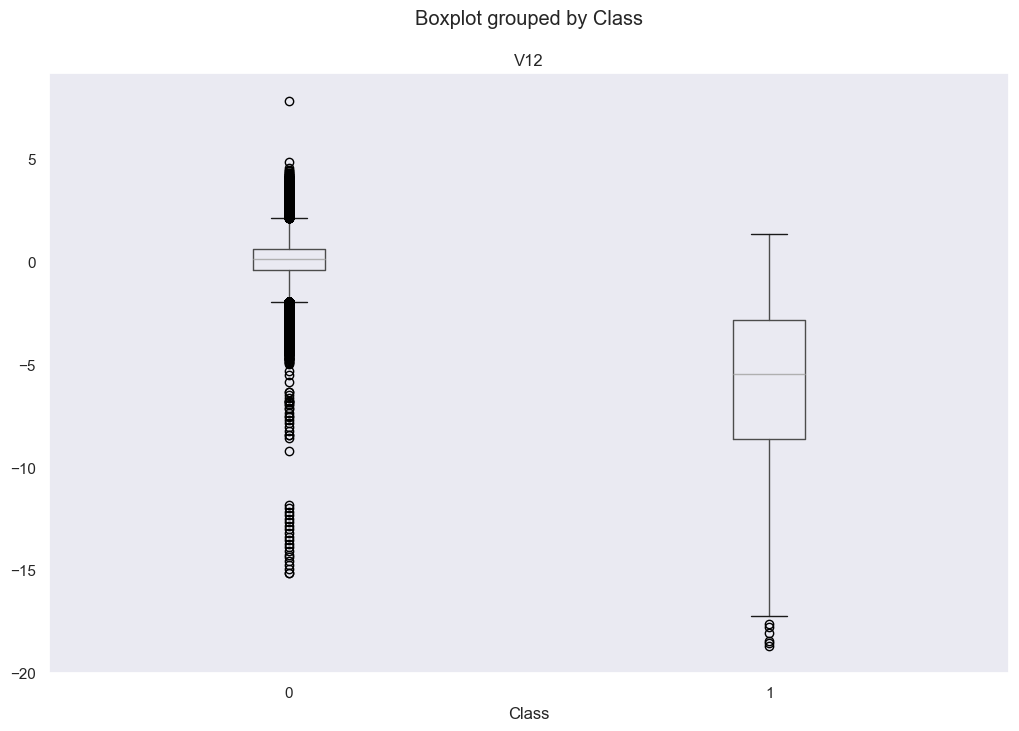

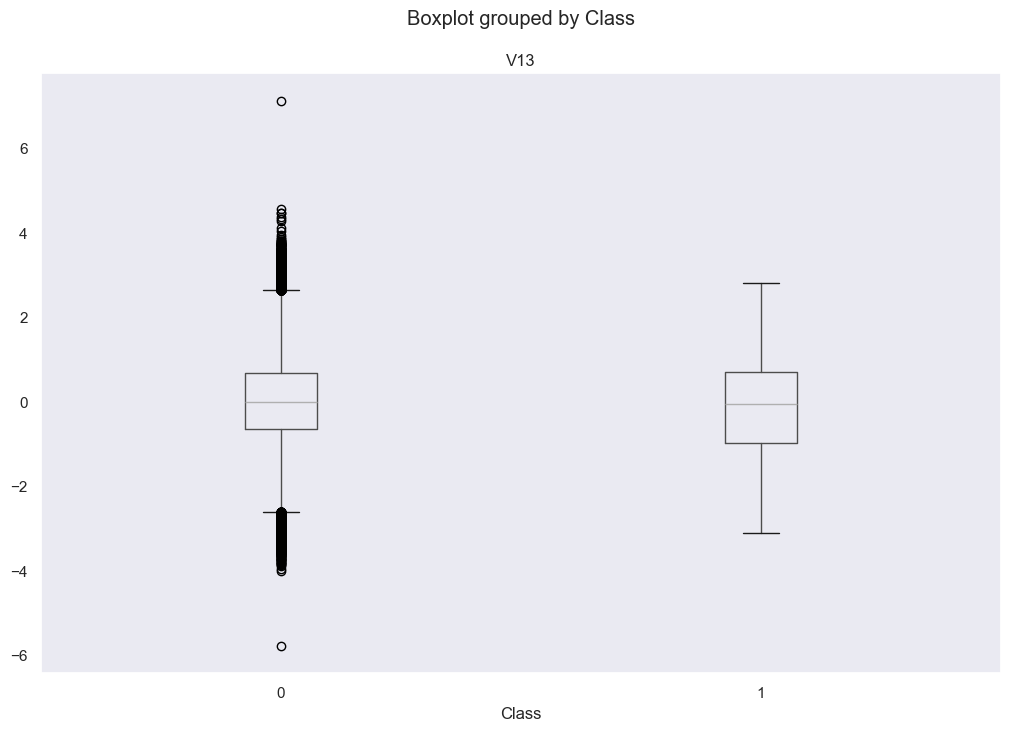

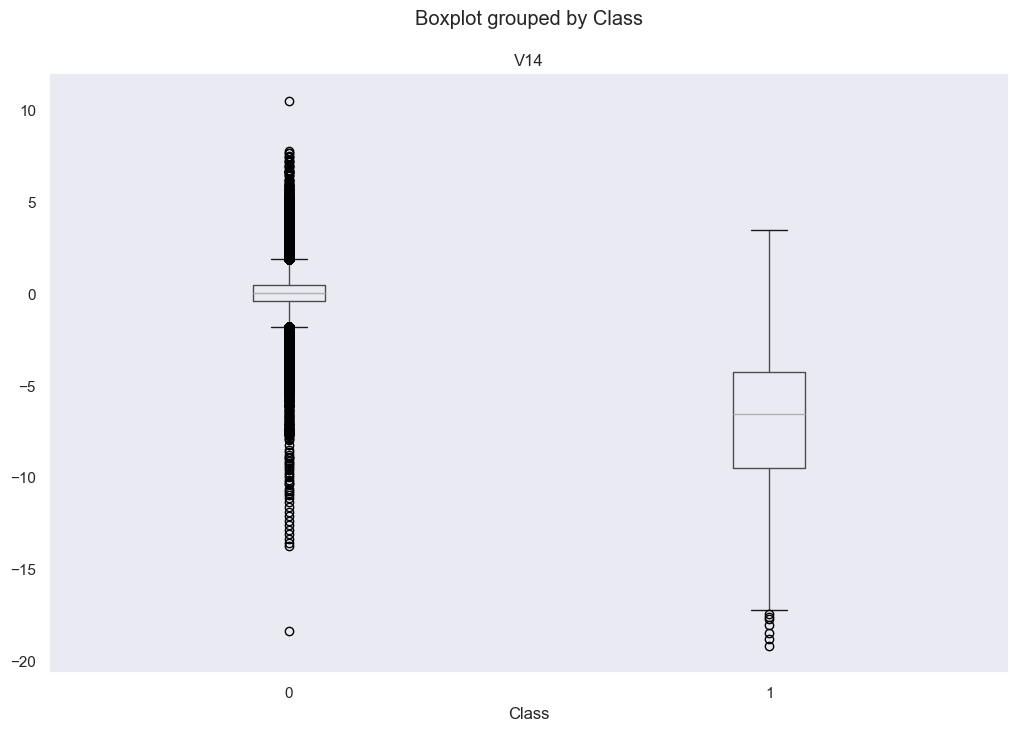

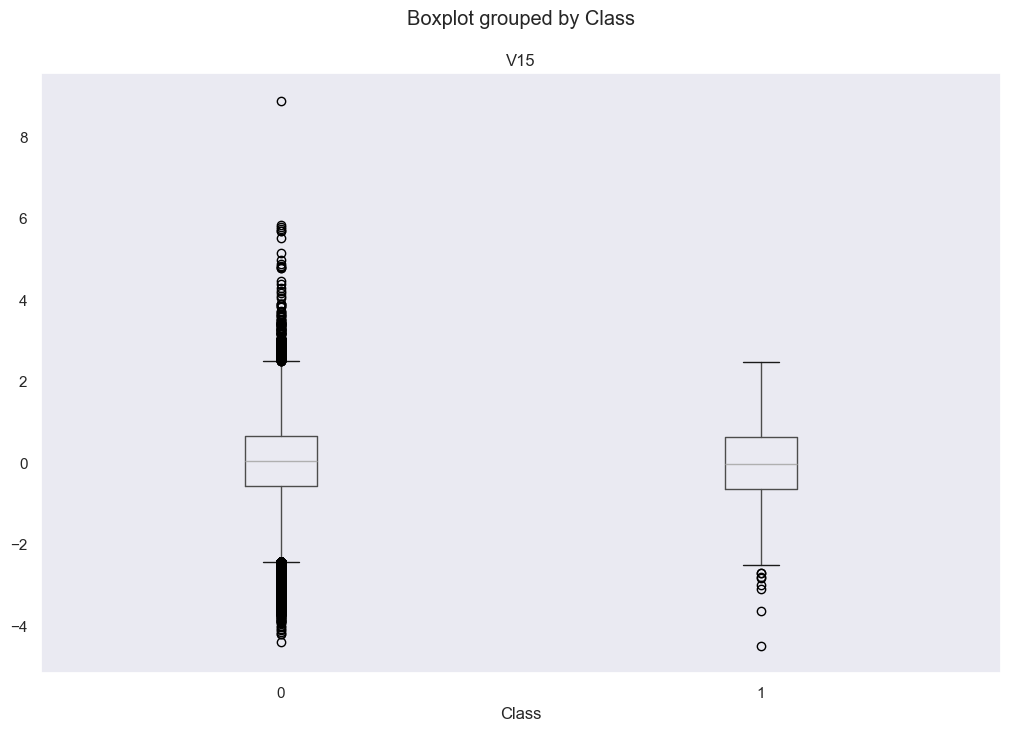

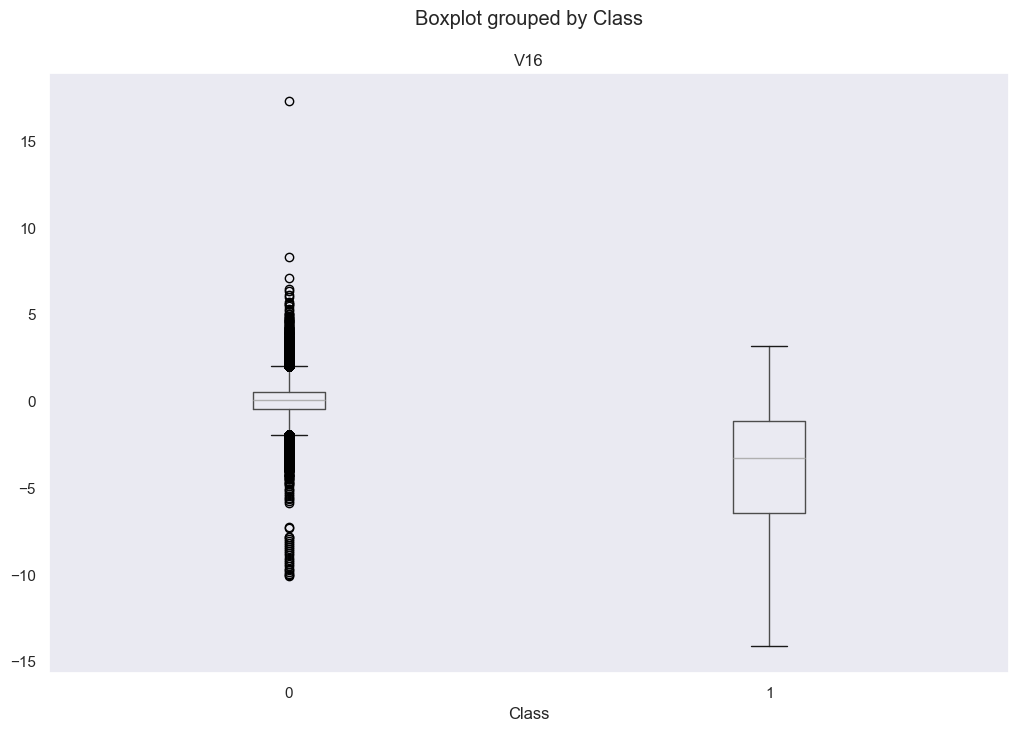

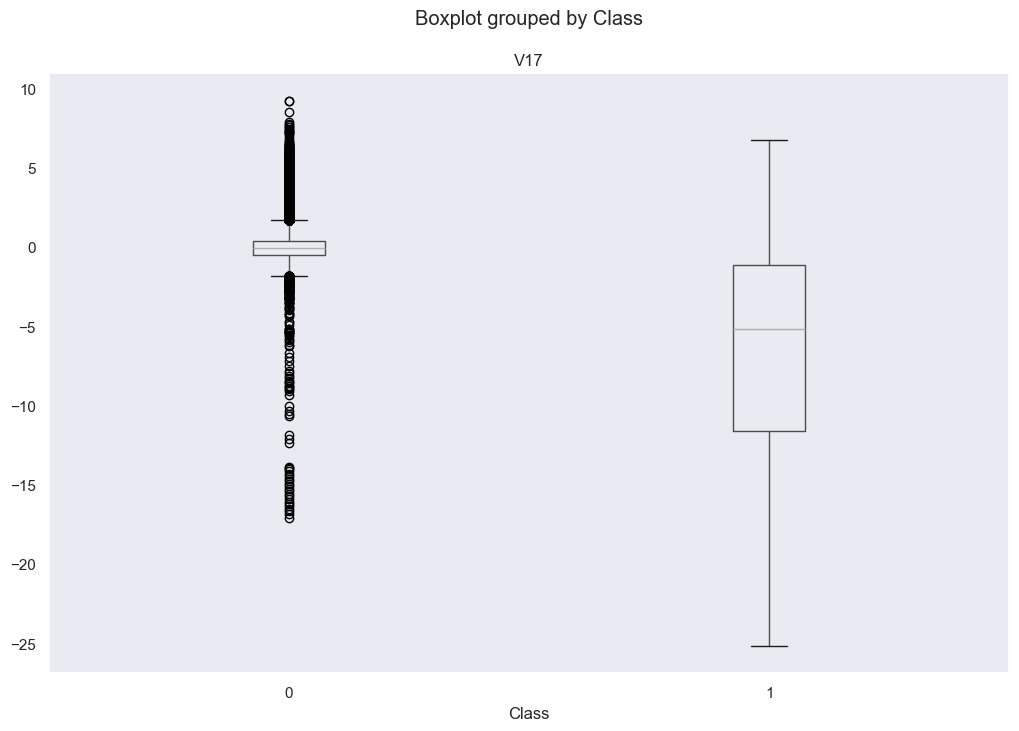

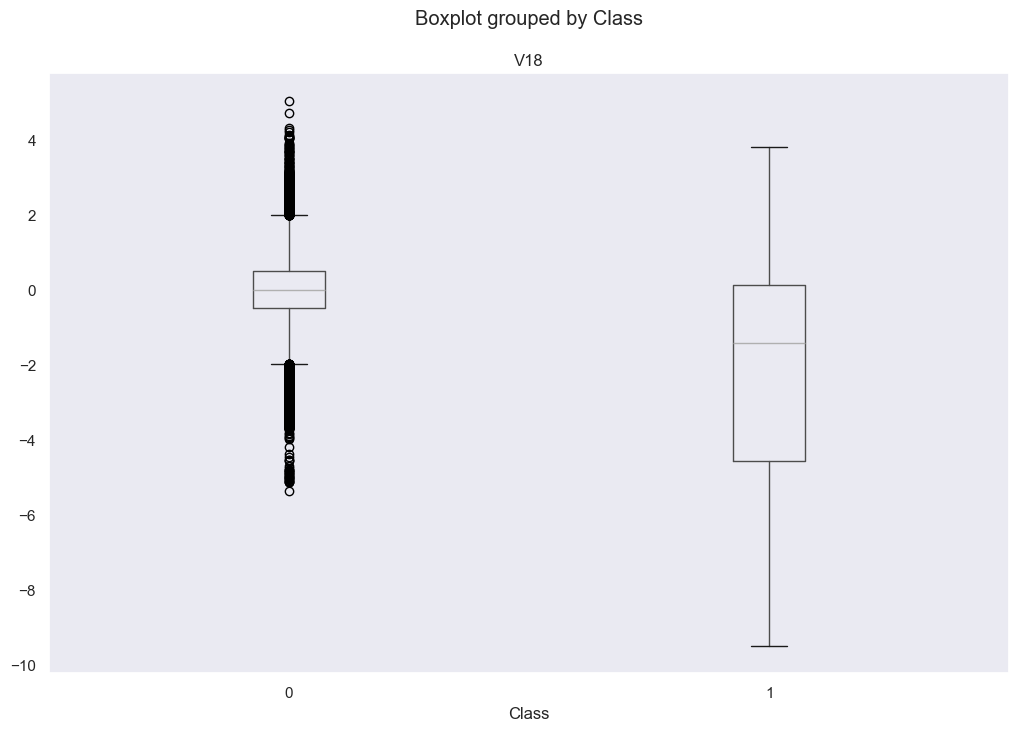

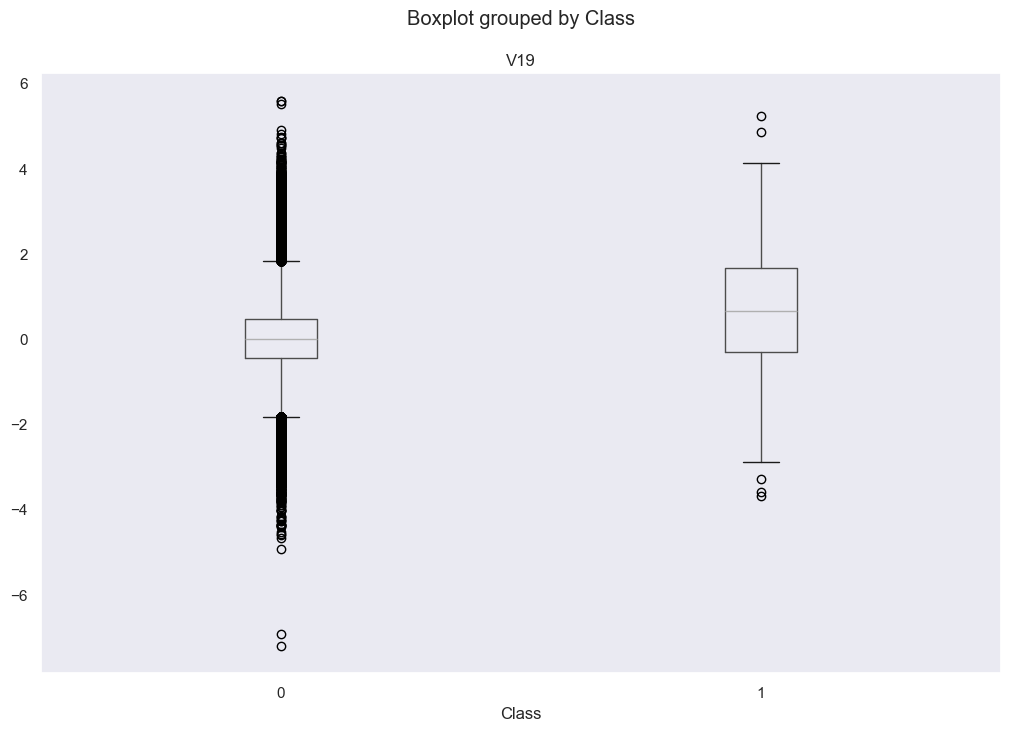

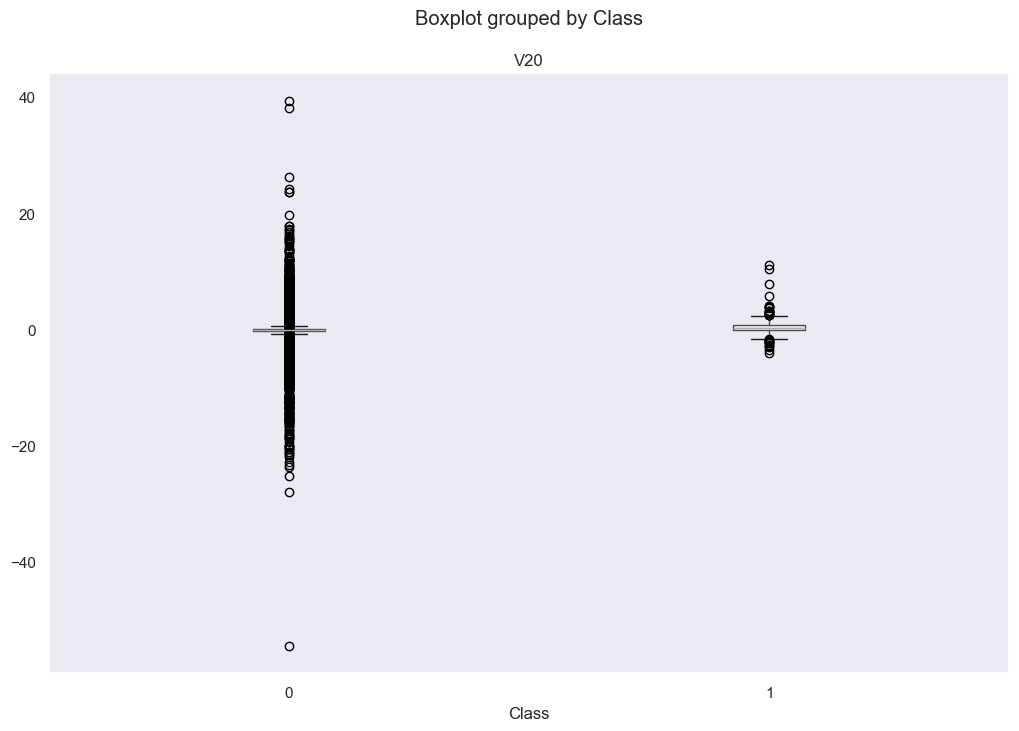

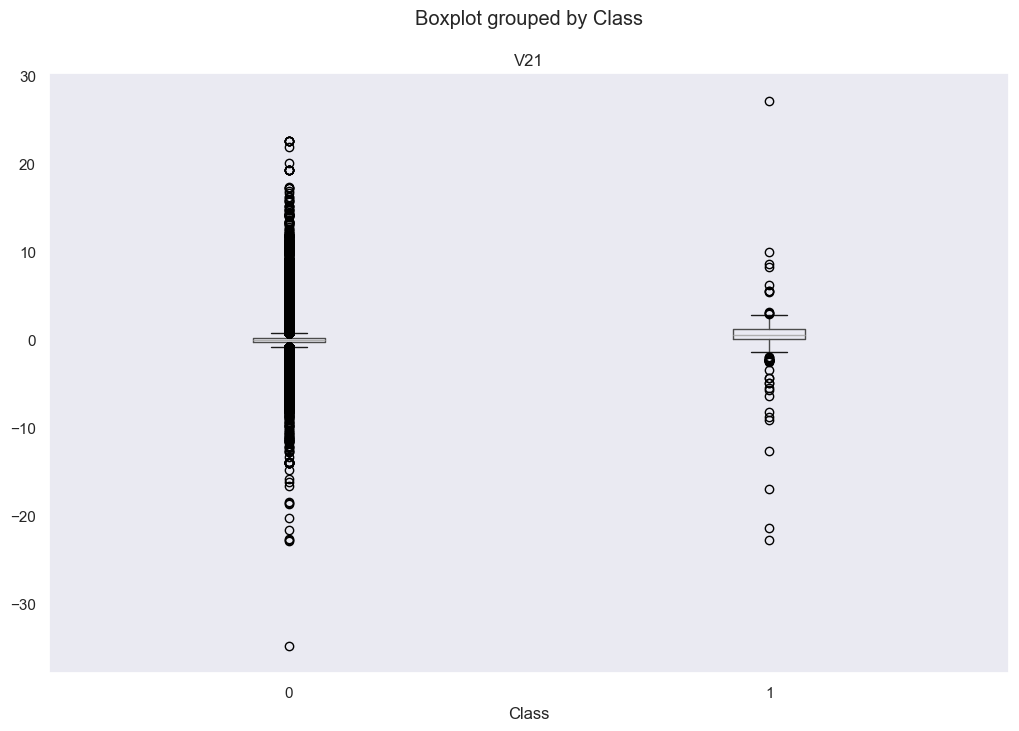

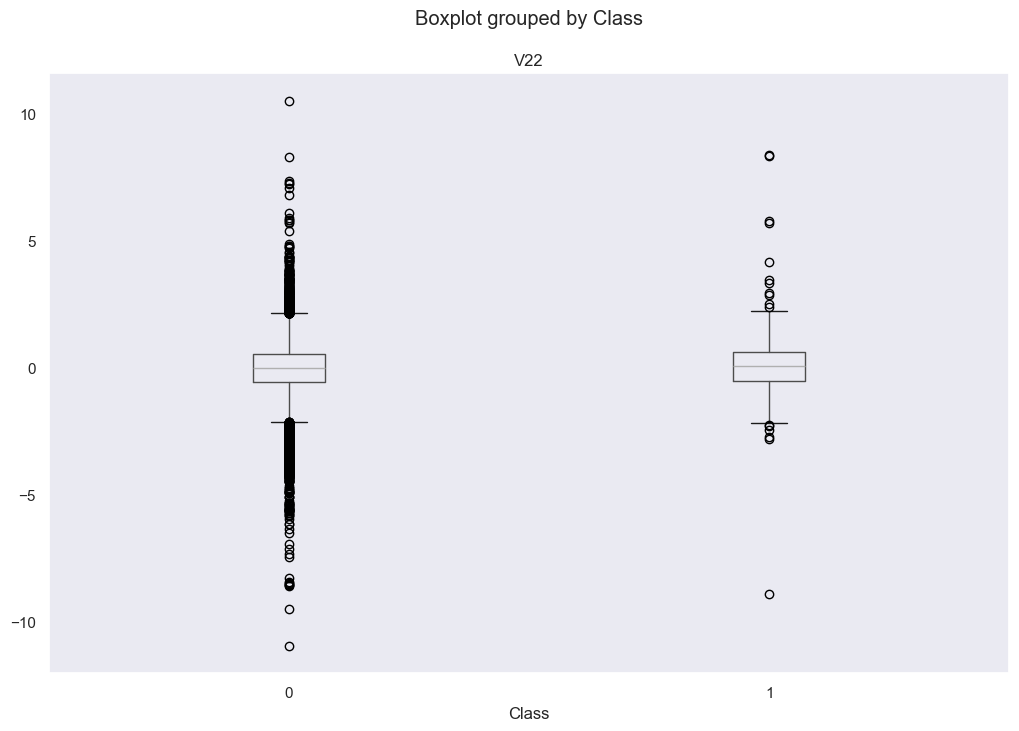

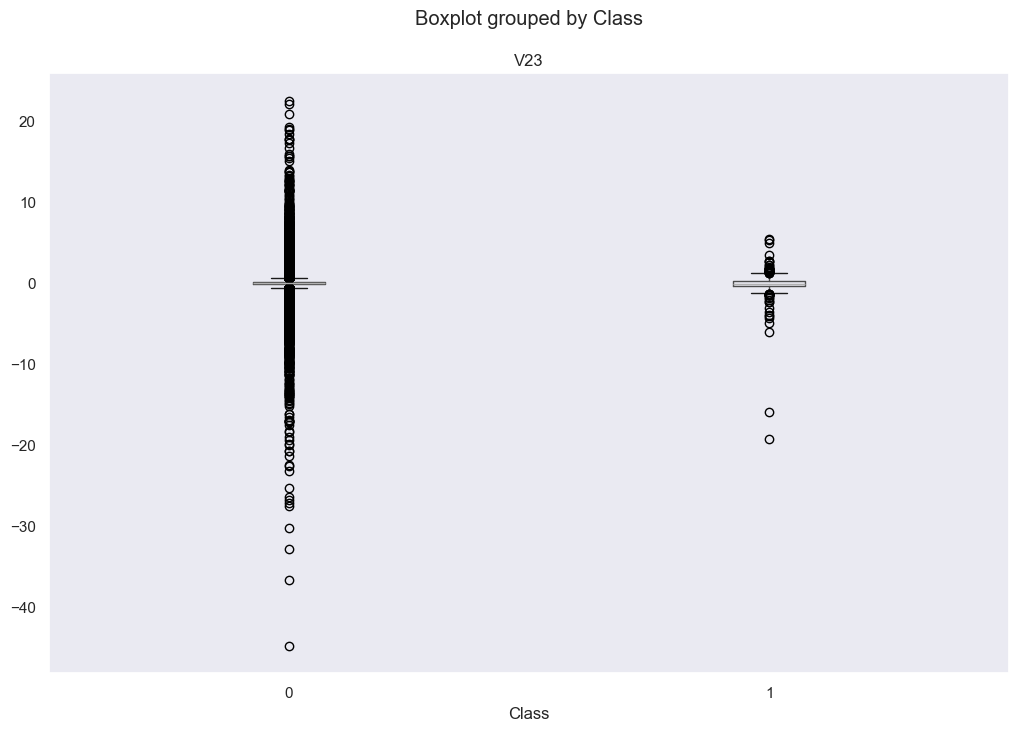

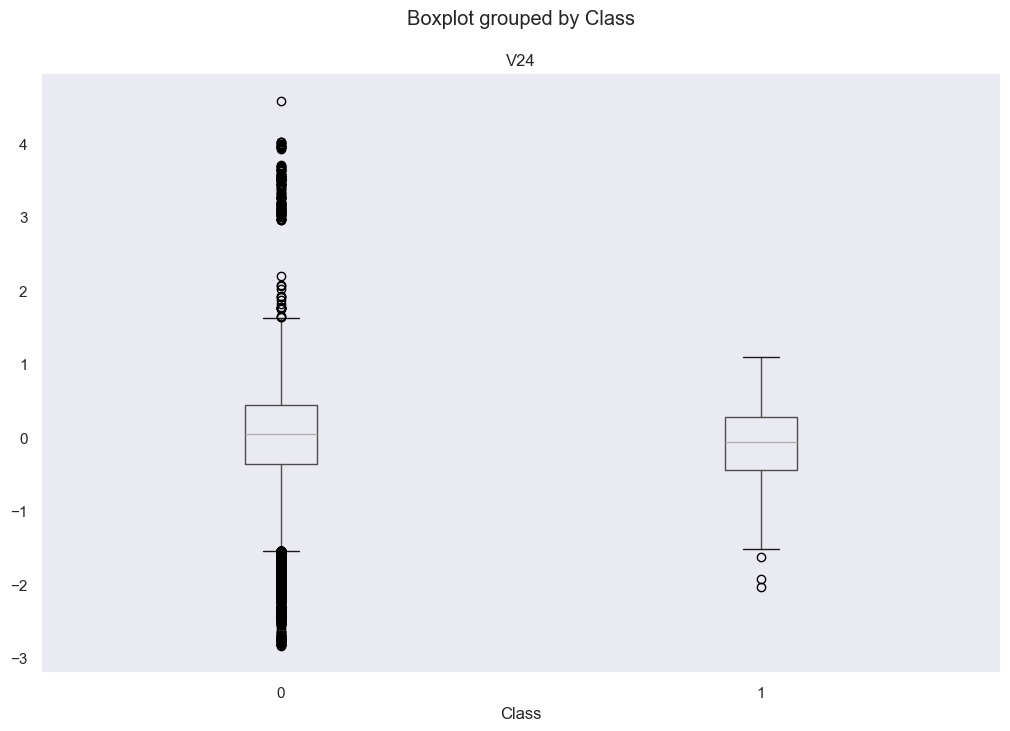

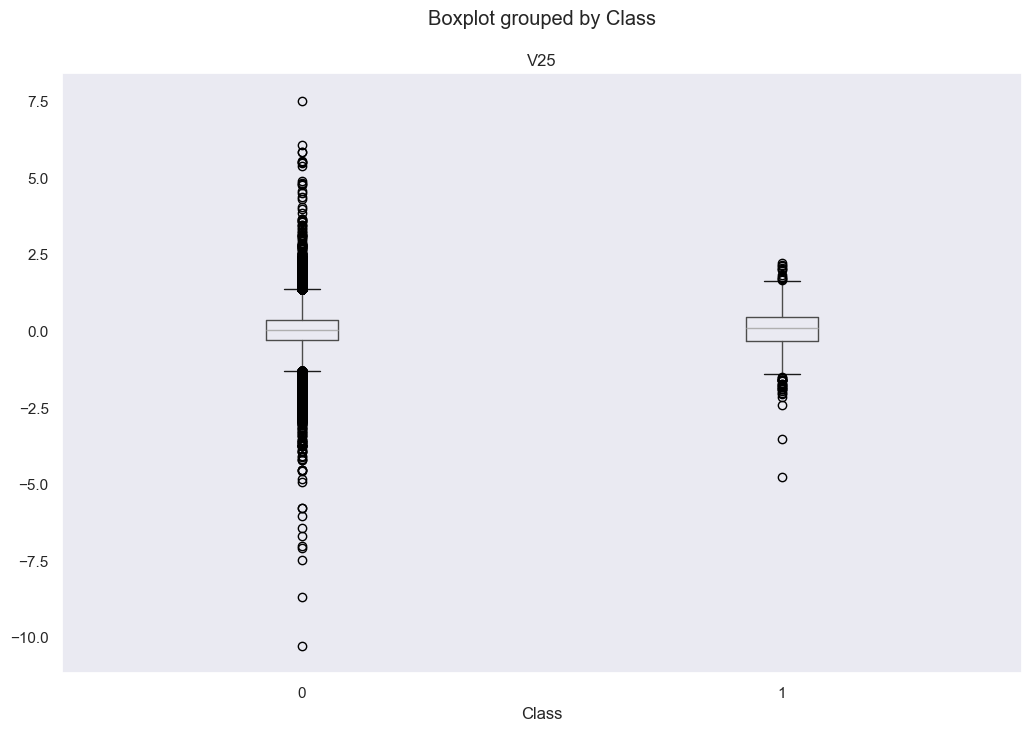

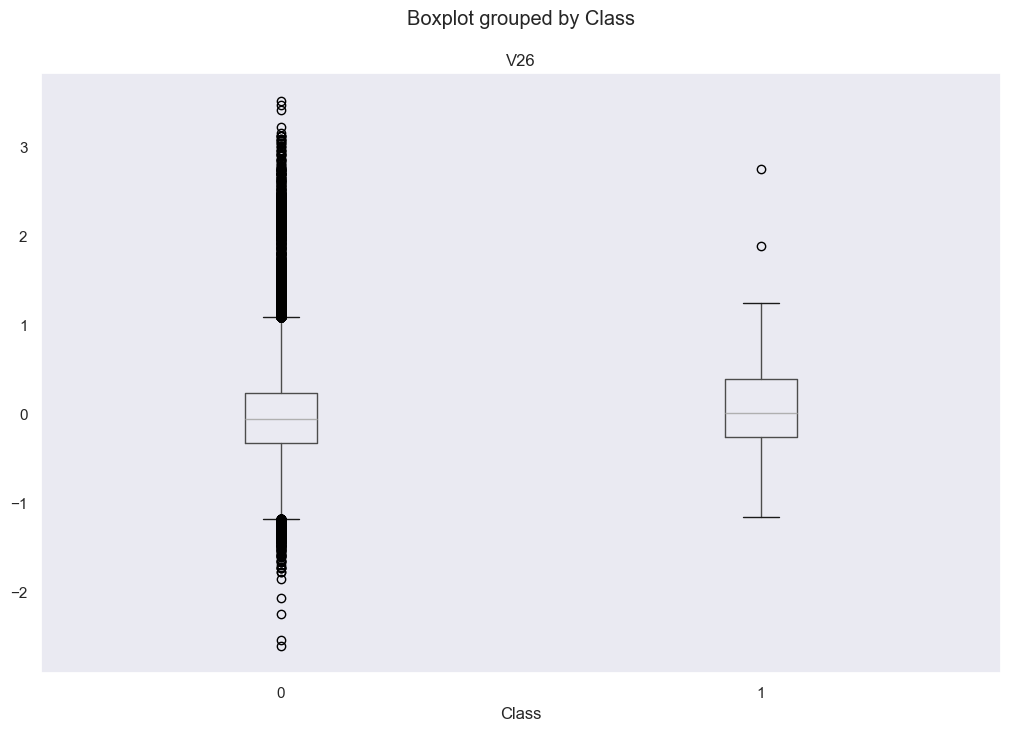

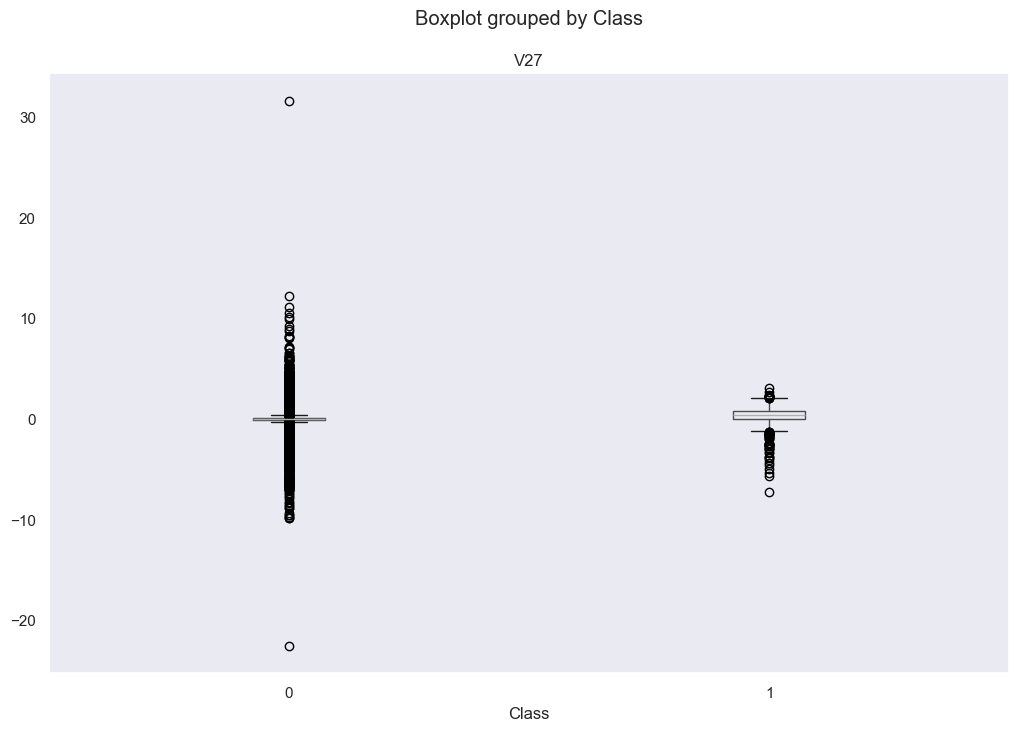

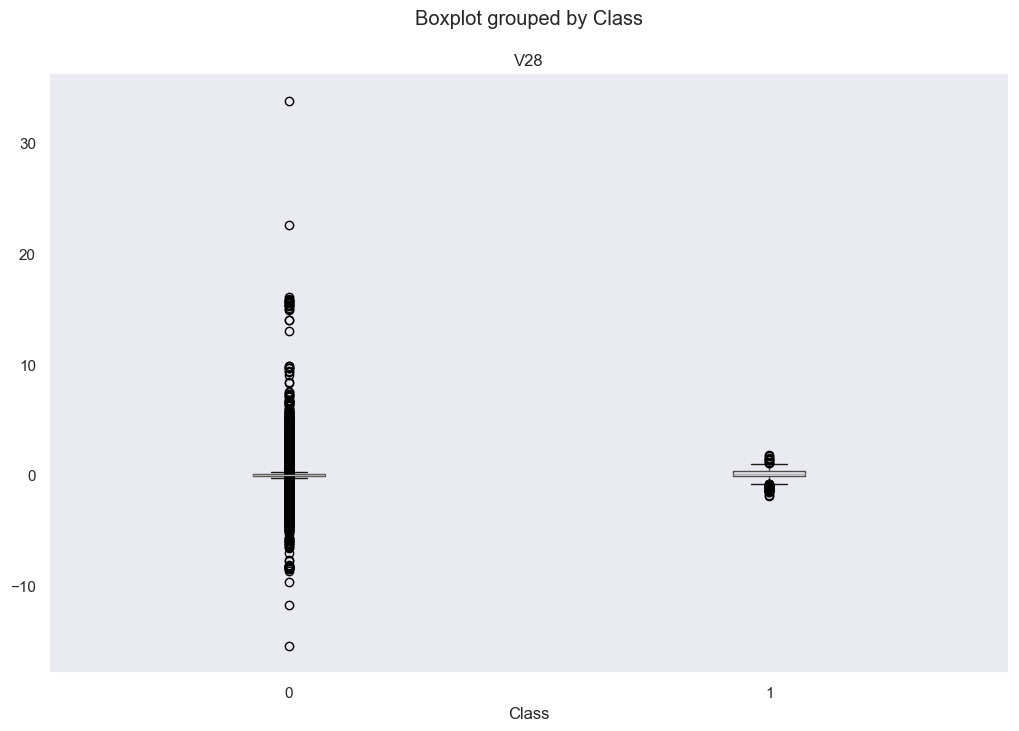

In [205]:
for i in range(1,29) :
    boxplot = credit.boxplot(grid=False, column='V'+ str(i), by='Class', figsize=(12,8))
plt.show()

In [206]:
from sklearn.preprocessing import StandardScaler, RobustScaler

rob_scaler = RobustScaler()

credit["scaled_amount"] = rob_scaler.fit_transform( credit["Amount"].values.reshape(-1, 1))

credit["scaled_time"] = rob_scaler.fit_transform( credit["Time"].values.reshape(-1, 1))

credit.drop(["Time_day", "Time"], axis=1).head()
 

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V23,V24,V25,V26,V27,V28,Amount,Class,scaled_amount,scaled_time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,1.774718,-0.995290
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,-0.268530,-0.995290
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,4.959811,-0.995279
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,1.411487,-0.995279
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,0.667362,-0.995267


In [207]:
credit[['scaled_time','scaled_amount']]


,scaled_time,scaled_amount
0,-0.995290,1.774718
1,-0.995290,-0.268530
2,-0.995279,4.959811
3,-0.995279,1.411487
4,-0.995267,0.667362
...,...,...
284802,1.035258,-0.295230
284803,1.035270,0.038798
284804,1.035282,0.638020
284805,1.035282,-0.166875


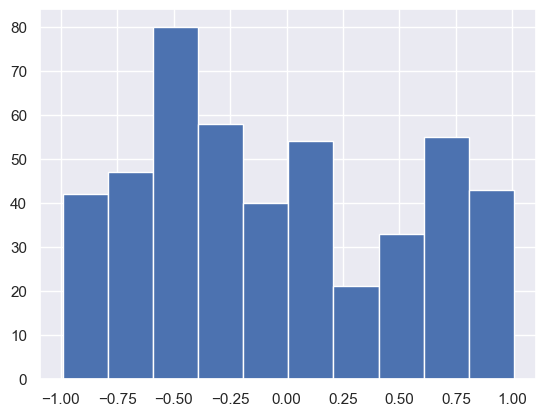

In [208]:
Fraud = credit[credit ["Class"] ==1]

Fraud ["scaled_time"]. hist()

plt.show()
 

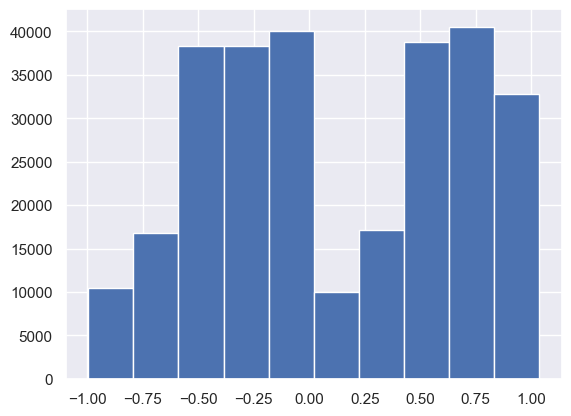

In [209]:
Valid = credit[credit ["Class"] ==0]

Valid ["scaled_time"]. hist()

plt.show()
 

In [210]:
rndperm = np.random.permutation(credit.shape [0])

In [211]:
N = min(10000, credit.shape[0])
print("N = ", N) 
df_subset = credit.iloc[:N].copy().dropna()

data_subset = df_subset.drop(["Time", "Amount", "Class"], axis=1).values

pca = PCA(n_components=3)

pca_result = pca.fit_transform(data_subset)

N =  10000


In [212]:
df_subset['pca-one'] = pca_result[:, 0]
df_subset['pca-two'] = pca_result[:, 1]
df_subset['pca-three'] = pca_result[:, 2]
print(df_subset.head(5))

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V27       V28  Amount  Class  Time_day  \
0  0.098698  0.363787  ...  0.133558 -0.021053  149.62      0  0.000000   
1  0.085102 -0.255425  ... -0.008983  0.014724    2.69      0  0.000000   
2  0.247676 -1.514654  ... -0.055353 -0.059752  378.66      0  0.000278   
3  0.377436 -1.387024  ...  0.062723  0.061458  123.50      0  0.000278   
4 -0.270533  0.817739  ...  0.219422  0.215153   69.99      0  0.000556   

   scaled_amount  scaled_time   pca-one   pca-two  pca-three  

In [213]:
time_start = time.time()

tsne = TSNE(n_components=2, verbose=0,perplexity=40,n_iter_without_progress=300)

tsne_results = tsne.fit_transform(data_subset)

print('t-SNE done! Time elapsed: {} seconds'.format(time.time() - time_start))

t-SNE done! Time elapsed: 38.951881408691406 seconds


In [214]:
df_subset['tsne-2d-one'] = tsne_results[:,0]
df_subset['tsne-2d-two'] = tsne_results[:,1]
print (df_subset[['tsne-2d-one','tsne-2d-two']])

       tsne-2d-one  tsne-2d-two
0       -12.301956    45.086063
1        30.537680    49.787670
2         8.621090    51.067600
3         7.270883    26.020555
4       -14.676759    41.102459
...            ...          ...
10037    45.148300    -8.102765
10038    33.192665   -69.749405
10039   -77.318710    -7.770407
10040   -17.063087   -75.955841
10041     6.102707   -57.424641

[10000 rows x 2 columns]


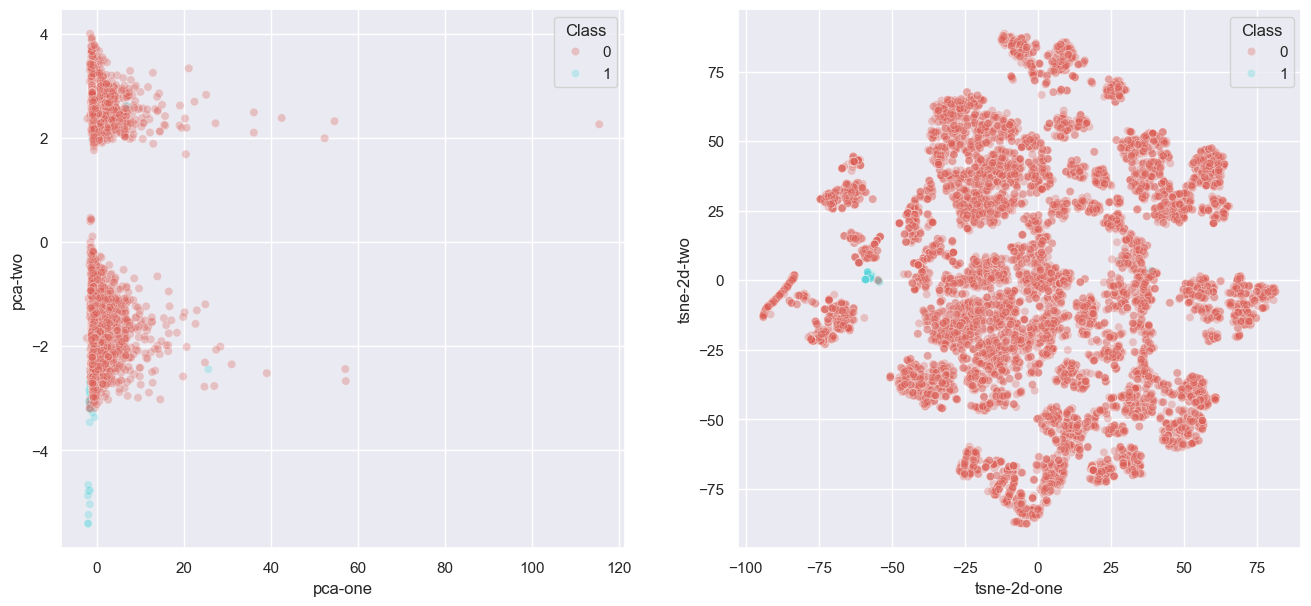

In [215]:
plt.figure(figsize=(16,7))
ax1 = plt.subplot(1, 2, 1)
sns.scatterplot(
    x="pca-one", y="pca-two",
    hue="Class",
    palette=sns.color_palette("hls", 2),
    data=df_subset,
    legend="full",
    alpha=0.3,
    ax=ax1
)

ax2 = plt.subplot(1, 2, 2)
sns.scatterplot(
    x="tsne-2d-one", y="tsne-2d-two",
    hue="Class",
    palette=sns.color_palette("hls", 2),
    data=df_subset,
    legend="full",
    alpha=0.3,
    ax=ax2
)

plt.show()

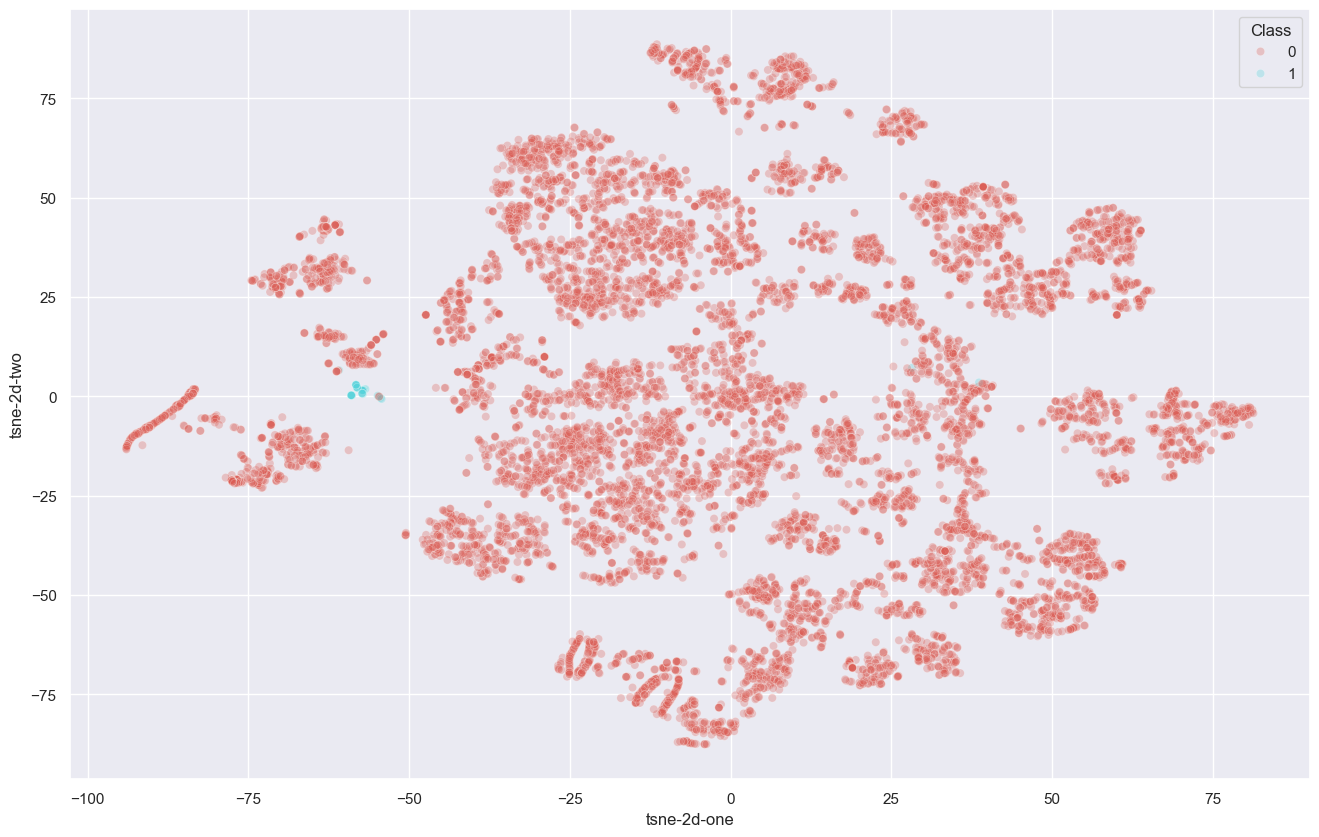

In [216]:
plt.figure(figsize=(16,10))

sns.scatterplot(
    x="tsne-2d-one",
    y="tsne-2d-two",
    hue="Class",
    palette=sns.color_palette("hls", 2),
    data=df_subset,
    legend="full",
    alpha=0.3
)

plt.show()

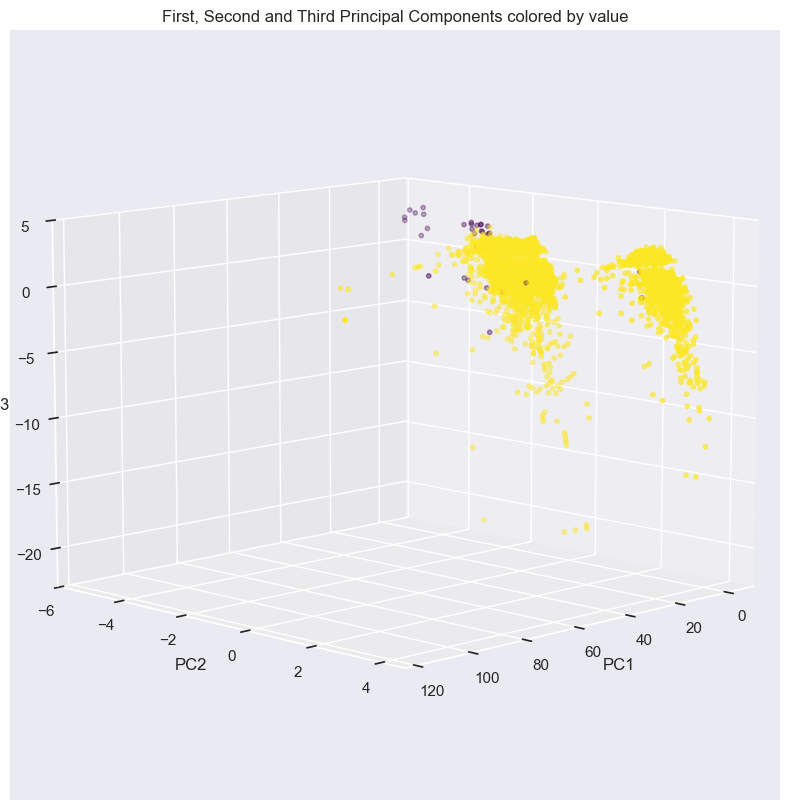

In [217]:
# Let's look at the PCA in 3D
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
 
ax.scatter(df_subset['pca-one'], df_subset['pca-two'], df_subset['pca-three'],cmap='viridis_r', c = df_subset['Class'], s=10)
 
# label the axes
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
 
ax.set_title("First, Second and Third Principal Components colored by value")
ax.view_init(10, 45)

In [218]:
time_start = time.time()
tsne = TSNE(n_components=3, verbose=0, perplexity=40,n_iter_without_progress=300)
tsne_results = tsne. fit_transform(data_subset)
print ('t-SNE done! Time elapsed: {} seconds'. format(time.time()-time_start))

t-SNE done! Time elapsed: 89.21224784851074 seconds


In [219]:
df_subset['tsne-3d-one'] = tsne_results[:,0]
df_subset ['tsne-3d-two'] = tsne_results[:,1]
df_subset ['tsne-3d-three'] = tsne_results[:,2]

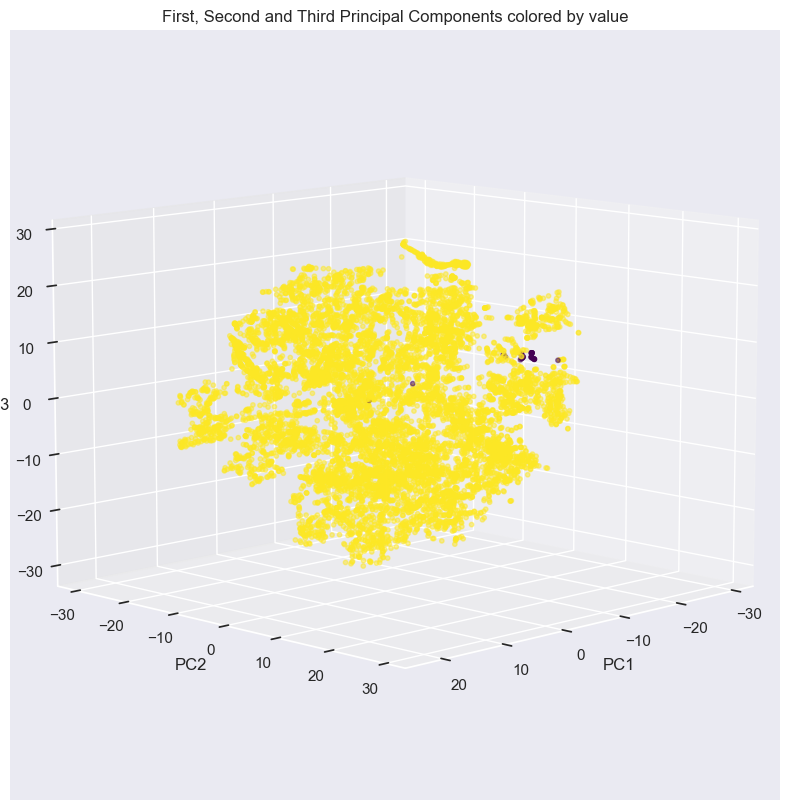

In [220]:
%matplotlib inline
 
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
 
ax.scatter(df_subset['tsne-3d-one'], df_subset['tsne-3d-two'], df_subset['tsne-3d-three'], cmap='viridis_r', c = df_subset['Class'], s=10, alpha=0.5)
 
# label the axes
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
 
ax.set_title("First, Second and Third Principal Components colored by value")
ax.view_init(10, 45)

5.

In [221]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, roc_curve, auc, accuracy_score, f1_score
 
# !pip install imbalanced-learn
from imblearn.over_sampling import SMOTE 
from imblearn.under_sampling import RandomUnderSampler
 

In [222]:

X = credit.drop('Class', axis=1)
y = credit['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.3,random_state=0,stratify=y)

In [223]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
accuracy_score(y_pred, y_test)

0.9993303414083977

In [224]:
f1_score(y_pred, y_test)

0.7865168539325843

In [225]:
y_score = lr.predict_proba(X_test)
fpr, tpr, _ = roc_curve(y_test, y_score[:,1])
roc_auc = auc(fpr, tpr)
roc_auc

0.9379188423707373

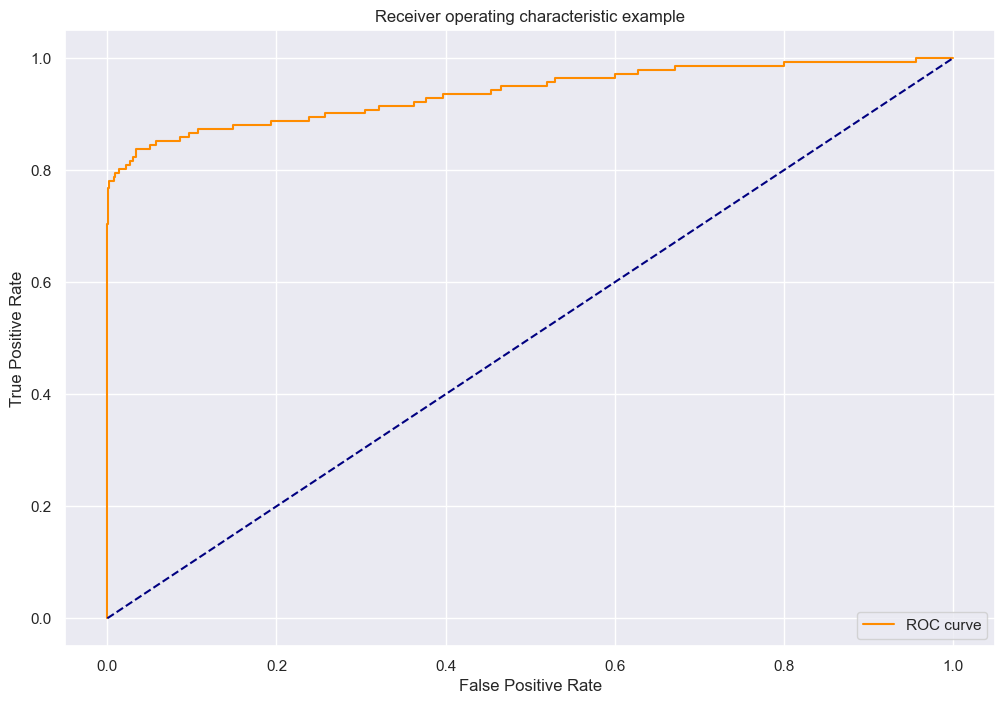

In [226]:
plt.figure(figsize=(12,8))
 
plt.plot(fpr, tpr, color='darkorange', label='ROC curve')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")
plt.show()

In [227]:
precision , recall, threshold = precision_recall_curve(y_test.values.reshape(-1,1), y_score[:,1])
print(auc(recall, precision))

0.6842905035767668


In [228]:
X = credit.drop('Class', axis=1)
y = credit['Class']

# Whole dataset split before resampling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y
)


In [229]:
sm = SMOTE(random_state=0)
X_res, y_res = sm.fit_resample(X_train, y_train)
X_res, y_res


(                 Time         V1        V2         V3        V4        V5  \
 0        38382.000000  -0.866903  1.018526   0.860412  1.025923  0.114208   
 1       138806.000000   2.189069 -0.987987  -1.103754 -1.141184 -0.467842   
 2       163459.000000  -0.379814 -0.152088   0.707194 -0.392085 -0.377484   
 3        50843.000000  -2.587342 -2.894117   1.428440 -2.217341 -2.134180   
 4       142869.000000   1.896828 -0.168844  -1.772662  0.520009  0.218424   
 ...               ...        ...       ...        ...       ...       ...   
 396549  129334.051990   1.182417  2.915869  -5.955835  5.489561  1.501288   
 396550   40697.230221  -4.267037  0.450650  -4.803266  6.520519  4.384540   
 396551   61577.617199  -4.768523  0.079136  -3.013023  4.908846 -5.680706   
 396552   25193.655551 -10.266283  7.221507 -12.892936  4.937284 -8.110591   
 396553  166127.470028  -2.048554 -0.586233  -2.330814  0.643226  0.724913   
 
               V6        V7        V8        V9  ...       V23

In [230]:
lr = LogisticRegression()
lr.fit(X_res, y_res)
y_pred = lr.predict(X_test)
accuracy_score(y_pred, y_test)

0.9812378110387932

In [231]:
f1_score(y_pred, y_test)

0.13908355795148247

In [232]:
y_score = lr.predict_proba(X_test)
fpr2, tpr2, _ = roc_curve(y_test, y_score[:,1])
roc_auc = auc(fpr2, tpr2)
roc_auc

0.9709013945279661

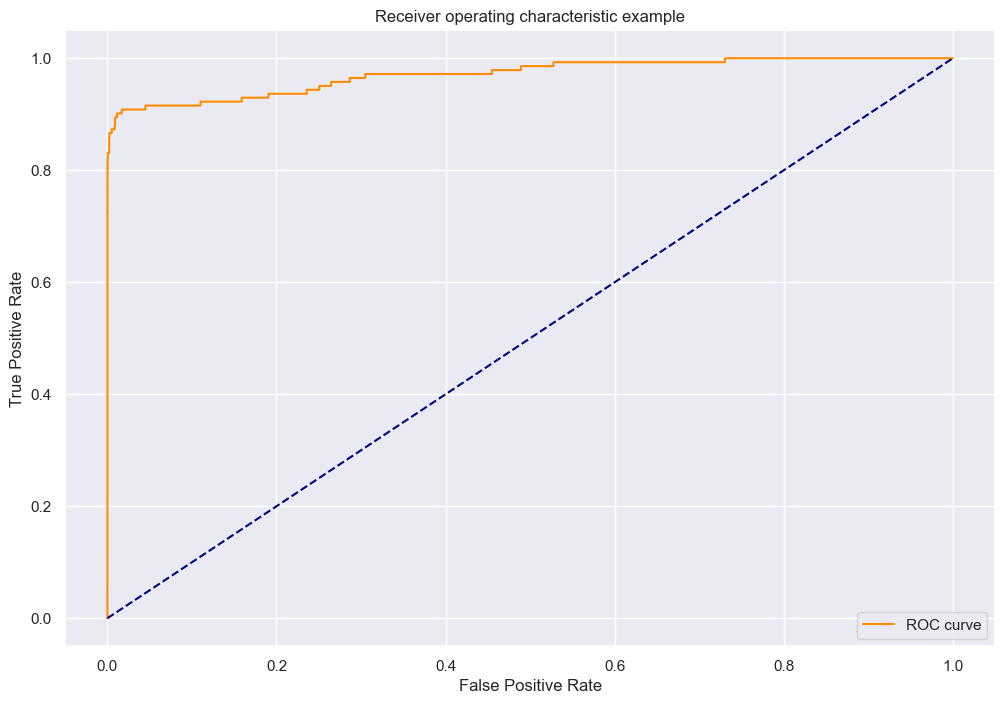

In [233]:
plt.figure(figsize=(12,8))
 
plt.plot(fpr2, tpr2, color='darkorange', label='ROC curve')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")
plt.show()

In [234]:
precision , recall, threshold = precision_recall_curve(y_test.values.reshape(-1,1), y_score[:,1])
print(auc(recall, precision))

0.7619623025871104


In [235]:
sm = RandomUnderSampler(sampling_strategy=0.5, random_state=42)
X_ures, y_ures = sm.fit_resample(X_train, y_train)

In [236]:
print(X_ures.shape)

(993, 33)


In [237]:
lr = LogisticRegression()
lr.fit(X_ures, y_ures)
y_pred = lr.predict(X_test)
accuracy_score(y_pred, y_test)

0.9795695387579595

In [238]:
f1_score(y_pred, y_test)

0.12832080200501253

In [239]:
y_score = lr.predict_proba(X_test)
fpr3, tpr3, _ = roc_curve(y_test, y_score[:,1])
roc_auc = auc(fpr3, tpr3)
roc_auc

0.9680993191781075

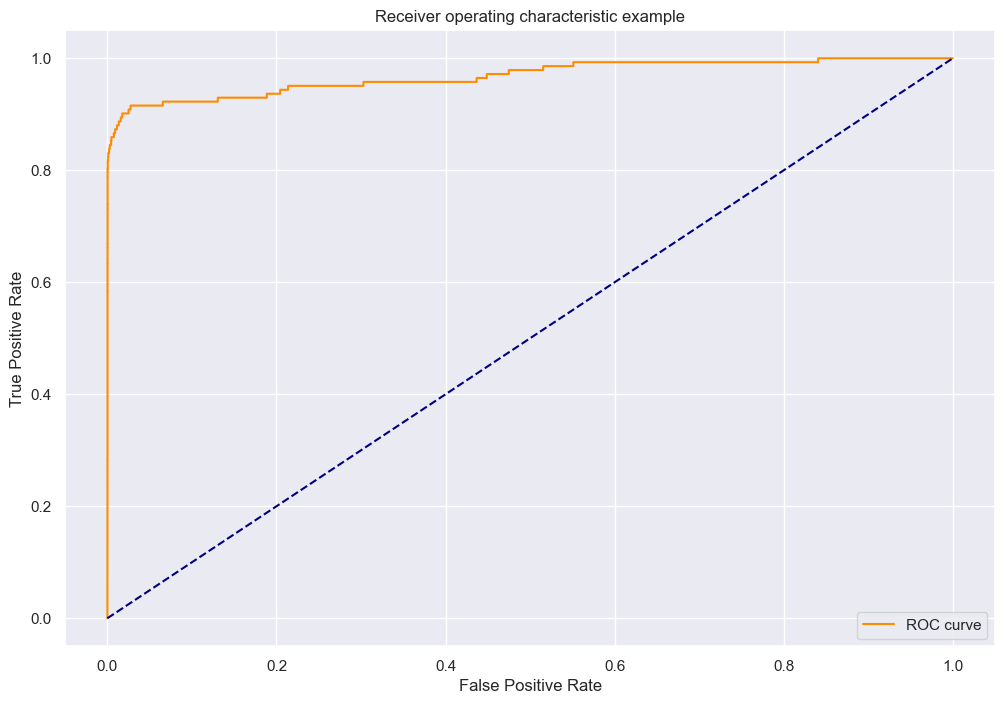

In [240]:
plt.figure(figsize=(12,8))
 
plt.plot(fpr3, tpr3, color='darkorange', label='ROC curve')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")
plt.show()

In [241]:
precision , recall, threshold = precision_recall_curve(y_test.values.reshape(-1,1), y_score[:,1])
print(auc(recall, precision))

0.7380872908175223
